In [ ]:
!pip install tensorflow

  Using cached tensorflow-2.20.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.0.1-cp310-cp310-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (9.0 kB)
  Using cached grpcio-1.76.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.7 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached ml_dtypes-0.5.4-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.met

# Innit


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random


from pycaret.regression import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.feature_selection import VarianceThreshold, RFE
from lightgbm import LGBMRegressor



import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F


def set_seeds(seed=42):
    """
    Sets the seed for reproducibility across Python, NumPy, and TensorFlow.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # 5. Enforce deterministic behavior (TF ≥ 2.9)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

    torch.manual_seed(seed)
    # For newer versions of TF/Keras to ensure deterministic behavior on GPU if possible
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    print(f"Random seed set to: {seed}")
set_seeds(42)

gw = 24

Random seed set to: 42


## Functions


In [56]:
def working_df(data, gw, features=None):

    GW_full = data['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'fpl_name': full_data[test_mask]['fpl_name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['fpl_name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


### AffinePNN


In [64]:
# --- Step 1: Data Preparation Function ---
def prepare_fpl_data(data, cols):
    """
    Prepares features (X), conditional parameters (M), targets (Y),
    and gameweeks (GW) for the AffinePNN model.
    """
    # cols_ = list(cols)
    # if 'team_difficulty' not in cols_:
    #     cols_.append('team_h_difficulty', 'team_a_difficulty')

    data_ = data.copy()

    # Target and metadata columns
    target_col = ['xP', 'fpl_name']
    gameweek_col = 'round'
    POSITION_COL = 'position'
    M_COLS = ['was_home', 'position_DEF', 'position_FWD', 'position_GK', 'position_MID','win_prob', 'draw_prob', 'lose_prob'] #, 'whh', 'whd', 'wha'

    # 2. Target Variable (Y)
    Y = data_[target_col].fillna(0)

    # 3. Input Features (X)
    EXCLUDE_COLS = [*target_col, gameweek_col, *M_COLS]

    # Find position-related columns for explicit inclusion if needed
    new_position_cols = [col for col in data_.columns if col.startswith(f'{POSITION_COL}_')]

    # Filter feature columns
    X_cols = [c for c in data_.columns if c not in EXCLUDE_COLS and c != POSITION_COL]

    # Final check of column existence
    X_cols = [col for col in X_cols if col in cols]

    # Convert to numpy
    X_ids = data_['fpl_id'].values
    X = data_[X_cols]#.drop(columns=['fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team',
    #    'opponent_team', 'was_home',])
    X = X.fillna(0).values.astype(np.float32)

    M = data_[M_COLS].fillna(0).values.astype(np.float32)
    GW = data_[gameweek_col].values



    print(f"Data prepared. X shape: {X.shape}, M shape: {M.shape}, Y shape: {Y.shape}")
    return X, M, Y, GW, X_cols, X_ids

def transform_data(final_df, cols, round):
    # Prepare data
    X_full, M_full, Y_full, GW_full, X_cols, X_ids = prepare_fpl_data(final_df, cols)
    # print(X_full.shape)
    # Split
    GW_TRAIN_END = round - 1
    # GW_TRAIN_START = GW_TRAIN_END - 10
    # train_mask = (GW_full >= GW_TRAIN_START) & (GW_full <= GW_TRAIN_END)
    # test_mask = GW_full == (GW_TRAIN_END + 1)

    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    X_train, M_train, Y_train_raw = X_full[train_mask], M_full[train_mask], Y_full[train_mask]
    X_test, M_test, Y_test_raw, X_test_ids = X_full[test_mask], M_full[test_mask], Y_full[test_mask], X_ids[test_mask]

    Y_train = Y_train_raw['xP'].values
    Y_train_names = Y_train_raw['fpl_name'].values

    Y_test = Y_test_raw['xP'].values
    Y_test_names = Y_test_raw['fpl_name'].values

    # Scaling
    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)

    if X_test.size > 0:
        X_test_scaled = scaler_x.transform(X_test)
    else:
        X_test_scaled = scaler_x

    scaler_m = StandardScaler()
    M_train_scaled = scaler_m.fit_transform(M_train)

    if M_test.size > 0:
        M_test_scaled = scaler_m.transform(M_test)
    else:
        M_test_scaled = scaler_m

    # Scale Y if needed
    scaler_y = MinMaxScaler()
    Y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1)).flatten()

    # print('----', Y_train)

    return (X_train_scaled, M_train_scaled, train_mask, Y_train, Y_train_names), (X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names, X_test_ids), GW_full, X_cols, scaler_y#, scaler_x, scaler_m


In [ ]:

# --- Step 2: Custom Affine Conditioning Layer ---
class AffineConditioning(Layer):
    """
    Custom Keras Layer implementing the core Affine Parametric Neural Network (AffinePNN) logic.
    z = (phi * m + s0) * x + (psi * m + b0)
    """
    def __init__(self, units, activation=None, **kwargs):
        super(AffineConditioning, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        # input_shape: [feature_input_shape, parameter_input_shape]
        feature_dim = input_shape[0][-1]
        param_dim = input_shape[1][-1]

        # Weights to transform the parameter 'm' into scale and bias adjustments
        # Shape is (param_dim, feature_dim) to map conditions to feature space
        self.phi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='phi')
        self.psi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='psi')

        # Base scaling and bias
        # self.s0 = self.add_weight(shape=(feature_dim,), initializer='ones', trainable=True, name='s0')
        self.b0 = self.add_weight(shape=(feature_dim,), initializer='zeros', trainable=True, name='b0')

        self.built = True

    def call(self, inputs):
        x_in, m = inputs # x_in: (batch, feat), m: (batch, cond)

        # Calculate scale and bias based on conditional input m
        # (batch, cond) @ (cond, feat) -> (batch, feat)
        s_m = tf.matmul(m, self.phi)
        b_m = tf.matmul(m, self.psi)

        s = 1.0 + 0.5 * tf.tanh(s_m) # s_m + self.s0
        b = b_m + self.b0

        # Apply affine transformation
        x_out = s * x_in + b

        if self.activation is not None:
            return self.activation(x_out)
        return x_out

    def get_config(self):
        config = super(AffineConditioning, self).get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
        })
        return config

# --- Step 3: Model Architecture ---
def build_affine_pnn(input_dim_x, input_dim_m, output_dim_y, hidden_units=128):
    """
    Builds the Affine Parametric Neural Network (AffinePNN) Model.
    """
    L2_REG = 0.005
    DROPOUT_RATE = 0.15

    X_input = Input(shape=(input_dim_x,), name='X_input')
    M_input = Input(shape=(input_dim_m,), name='M_input')

    # Initial Dense Layer
    x = Dense(hidden_units, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_1')(X_input)
    x = BatchNormalization()(x)
    # Affine Conditioning Block 1
    x = AffineConditioning(units=hidden_units, activation='tanh', name='Affine_Cond_1')([x, M_input])
    x = Dropout(DROPOUT_RATE)(x) # Added dropout for better generalization

    # Standard Dense Layer
    x = Dense(hidden_units // 2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_2')(x)

    # Affine Conditioning Block 2
    x = AffineConditioning(units=hidden_units // 2, activation='relu', name='Affine_Cond_2')([x, M_input])

    # Final Prediction Layer
    output = Dense(output_dim_y,
                activation='sigmoid',
                name='Output')(x)

    model = Model(inputs=[X_input, M_input], outputs=output, name='AffinePNN_FPL')
    return model

def plot_training_history(history, round):
    """
    Plots the training and validation loss/metrics including MSE.
    """
    metrics = ['loss', 'mae', 'mse']
    plt.figure(figsize=(18, 5))


    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i + 1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Validation')
        plt.title(f'GW ({round}): Model {metric.upper()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric.upper())
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

def apnn_trainer(data, cols, round):
    train_data, test_data , GW_full, X_cols,scaler_y = transform_data(data, cols, round)
    X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
    X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names, X_test_ids = test_data


    # Reduce features with low variance (nearly constant)
    vt = VarianceThreshold(threshold=1e-4)
    X_train_clean = vt.fit_transform(X_train_scaled)
    X_test_clean = vt.transform(X_test_scaled)

    pca = PCA(n_components=0.80, random_state=42)  # keep 95% variance
    X_train_pca = pca.fit_transform(X_train_clean)
    X_test_pca = pca.transform(X_test_clean)

    y_min, y_max = Y_train.min(), Y_train.max()
    scaler_y = (y_max - y_min)
    # training
    y_train_scaled = (Y_train - y_min) / scaler_y

    Y_test_scaled = (Y_test - y_min) / scaler_y


    # Model Setup
    INPUT_DIM_X = X_train_pca.shape[1]
    INPUT_DIM_M = M_train_scaled.shape[1]
    OUTPUT_DIM_Y = 1

    model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
    model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

    # Callbacks
    # 1. Reduce Learning Rate on Plateau
    # Helps the model 'settle' into the global minimum during the final epochs.
    lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-4, #verbose=1
    )

    # 2. Early Stopping
    # Prevents overfitting by stopping once validation performance stops improving.
    early_stopper = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True, verbose=1
    )

    # Training
    print("\nStarting Training...")
    history = model.fit(
        [X_train_pca, M_train_scaled], y_train_scaled,
        epochs=100, # Increased epochs with early stopping
        batch_size=32,
        validation_split=0.2,
        callbacks=[lr_reducer, early_stopper],
        verbose=1
    )

    evaluation_metrics_scaled = evaluator(model, X_test_pca, M_test_scaled, Y_test_scaled)

    test_loss = evaluation_metrics_scaled['test_loss']
    test_mae = evaluation_metrics_scaled['test_mae'] * scaler_y
    test_mse = evaluation_metrics_scaled['test_mse'] * scaler_y**2
    test_r2 = evaluation_metrics_scaled['test_R2']


    evaluation_metrics = {
        'test_loss': test_loss,
        'test_mae': test_mae,
        'test_mse': test_mse,
        'test_R2': test_r2
    }
    # Prediction
    print("\nGenerating Predictions...")
    Y_pred_scaled = model.predict([X_test_pca, M_test_scaled]).flatten()

    # inference
    Y_pred = Y_pred_scaled * scaler_y + y_min

    position = active_data['position'][test_mask]
    teams = active_data['team'][test_mask]
    players_preds = {'fpl_name': Y_test_names, 'fpl_id': X_test_ids, 'team': teams, 'position': position, 'Actual_xP': Y_test, 'Predicted_xP': Y_pred}
    preds_df = pd.DataFrame(players_preds)

    return history, evaluation_metrics, preds_df, scaler_y

def evaluator(model, X_test_scaled, M_test_scaled, Y_test):
    # 1. EVALUATE TEST SET PERFORMANCE using model.evaluate
    print("\nEvaluating test set performance...")
    test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

    # Generate predictions to calculate R2 score manually
    Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()
    r2 = r2_score(Y_test, Y_pred)

    evaluation_metrics = {
        'test_loss': test_results['loss'],
        'test_mae': test_results['mae'],
        'test_mse': test_results['mse'],
        'test_R2': r2
    }


    return evaluation_metrics

def plot_preds(preds_df, position, gw):
    Y_test_names = preds_df[preds_df['position'] == position]['fpl_name'].values
    Y_test = preds_df[preds_df['position'] == position]['Actual_xP'].values
    Y_pred = preds_df[preds_df['position'] == position]['Predicted_xP'].values

    # Convert names to positions on x-axis
    x = np.arange(len(Y_test_names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position(GW {gw})")
    plt.legend()
    plt.tight_layout()

    plt.show()



    # Index positions for players
    x = np.arange(len(Y_test_names))

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, Y_test, width, label='Actual Points')
    plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position(GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Calculate absolute errors
    errors = np.abs(Y_test - Y_pred)

    # Index for players
    x = np.arange(len(Y_test_names))
    width = 0.31  # width of the bars

    plt.figure(figsize=(16, 6))

    # Plot Actual and Predicted points side-by-side
    plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
    plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

    # Annotate absolute errors on top of predicted bars
    for i in range(len(Y_test_names)):
        plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

    # Labels and formatting
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.ylabel("Points")
    plt.title(f"{position}: Actual vs Predicted Points per Player (with Absolute Error) (GW {gw})")
    plt.legend()
    plt.tight_layout()

    plt.show()


# Data Prep


In [ ]:
# data_25_26 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
data_25_26 = pd.read_csv('../Prediction with Affine PNN/data/rolled_player_data.csv')
data_25_26

,fpl_id,round,first_name,second_name,web_name,now_cost,selected_by_percent,form,event_points,transfers_in_event,...,strength_attack_away_5_ewm,strength_defence_home_1_ewm,strength_defence_home_3_ewm,strength_defence_home_5_ewm,strength_defence_away_1_ewm,strength_defence_away_3_ewm,strength_defence_away_5_ewm,opp_clean_sheets,opp_elo,opp_strength
0,1.0,1,David,Raya Martín,Raya,6.0,36.9,3.2,10.0,418466.0,...,0.000000,0.0,0.00,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,1.0,2,David,Raya Martín,Raya,5.5,21.5,8.0,6.0,77335.0,...,1350.000000,1290.0,1290.00,1290.000000,1300.0,1300.0,1300.000000,1.000000,2037.000000,4.000000
2,1.0,3,David,Raya Martín,Raya,5.5,21.8,6.0,2.0,38830.0,...,1350.000000,1290.0,1290.00,1290.000000,1300.0,1300.0,1300.000000,1.000000,1993.000000,5.000000
3,1.0,4,David,Raya Martín,Raya,5.5,23.5,6.0,6.0,33143.0,...,1350.000000,1290.0,1290.00,1290.000000,1300.0,1300.0,1300.000000,1.000000,2037.000000,4.000000
4,1.0,5,David,Raya Martín,Raya,5.5,24.0,4.0,2.0,95889.0,...,1350.000000,1290.0,1290.00,1290.000000,1300.0,1300.0,1300.000000,0.000000,2037.000000,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7305,793.0,24,George,King,King,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.00,0.000000,0.0,0.0,0.000000,0.385276,1820.450044,3.083293
7306,794.0,21,Max,Alleyne,Alleyne,4.5,0.0,4.0,4.0,3483.0,...,0.000000,0.0,0.00,0.000000,0.0,0.0,0.000000,0.274660,1842.056122,3.176020
7307,794.0,22,Max,Alleyne,Alleyne,4.5,0.0,2.5,1.0,728.0,...,410.000000,1290.0,645.00,430.000000,1380.0,690.0,460.000000,0.264056,1842.221088,3.158113
7308,794.0,24,Max,Alleyne,Alleyne,0.0,0.0,1.7,0.0,0.0,...,455.555556,0.0,483.75,477.777778,0.0,517.5,511.111111,0.273932,1842.515038,3.138643


In [33]:

gw=24

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'opponent_team', 'was_home', 'xP',# 'xP_next',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'cbitr_volume_90', 'cbitr_ewm_90', 'cbitr_ewm_probability',  'cbitr_probability','elo',  'team_h_difficulty', 'team_a_difficulty',
    'win_prob', 'draw_prob', 'lose_prob',


    'creativity_rolling_1', 'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1',
    'threat_rolling_3', 'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3',
    'pts_bonus_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1',
    'expected_assists_rolling_3', 'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1',
    'expected_goals_conceded_rolling_3', 'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5',
    'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1',
    'key_passes_rolling_3', 'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5',
    'goals_rolling_1', 'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5',
    'saves_rolling_1', 'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3',
    'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5',
    'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1',
    'transfers_in_rolling_3', 'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5',

    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm',
    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm',
    'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm',
    'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm',
    'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm',
    'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm', 'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',
    'form_1_ewm', 'form_3_ewm', 'form_5_ewm', 'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',
    'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm',
    'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm',
    'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm',
    'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm',
    'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)

hist_data = data_25_26[
    (data_25_26['round'] > 5)  &
    (data_25_26['minutes_rolling_3'] > 15) &
    (data_25_26['minutes'] > 15)
    ]
tar_data = data_25_26[(data_25_26['round'] == gw) & (data_25_26['minutes_rolling_3'] >= 15)]

data_25_26_ = pd.concat([hist_data, tar_data])

active_data = data_25_26_[cols].copy()
active_data_ = active_data.copy()

CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
data = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)

feature_cols = [
    'selected_by_percent', 'value', 'transfers_in', 'transfers_out', 'selected', 'ownership_change', 'percenatge_net_transfers', 'cbitr_volume_90', 'cbitr_ewm_90',
    'cbitr_ewm_probability', 'cbitr_probability', 'elo', 'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob', 'creativity_rolling_1',
    'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1', 'threat_rolling_3',
    'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3', 'pts_bonus_rolling_5',
    'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1', 'expected_assists_rolling_3',
    'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1', 'expected_goals_conceded_rolling_3',
    'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5', 'goals_scored_rolling_1',
    'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1', 'key_passes_rolling_3',
    'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5', 'goals_rolling_1',
    'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5', 'saves_rolling_1',
    'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1', 'yellow_cards_rolling_3',
    'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3', 'assists_rolling_5',
    'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5', 'ict_index_rolling_1',
    'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1', 'transfers_in_rolling_3',
    'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5', 'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm',
    'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm',
    'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm', 'expected_goals_5_ewm', 'expected_assists_1_ewm',
    'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm',
    'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm',
    'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm',
    'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm',
    'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm', 'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm',
    'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm',
    'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm', 'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm',
    'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm',
    'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm',
    'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'form_1_ewm', 'form_3_ewm', 'form_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm',
    'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm',
    'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm',
    'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm',
    'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'opp_elo',
    'opp_clean_sheets', 'opp_strength', 'position_DEF', 'position_FWD', 'position_GK', 'position_MID', 'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth',
    'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton', 'team_Fulham', 'team_Leeds', 'team_Liverpool',
    'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland', 'team_West Ham', 'team_Wolves', 'opponent_team_Arsenal',
    'opponent_team_Aston Villa', 'opponent_team_Bournemouth', 'opponent_team_Brentford', 'opponent_team_Brighton', 'opponent_team_Burnley', 'opponent_team_Chelsea',
    'opponent_team_Crystal Palace', 'opponent_team_Everton', 'opponent_team_Fulham', 'opponent_team_Leeds', 'opponent_team_Liverpool', 'opponent_team_Man City',
    'opponent_team_Man Utd', 'opponent_team_Newcastle', "opponent_team_Nott'm Forest", 'opponent_team_Spurs', 'opponent_team_Sunderland', 'opponent_team_West Ham',
    'opponent_team_Wolves'
]

data

,fpl_id,round,fpl_name,team_id,was_home,xP,selected_by_percent,value,transfers_in,transfers_out,...,opponent_team_Leeds,opponent_team_Liverpool,opponent_team_Man City,opponent_team_Man Utd,opponent_team_Newcastle,opponent_team_Nott'm Forest,opponent_team_Spurs,opponent_team_Sunderland,opponent_team_West Ham,opponent_team_Wolves
5,1.0,6,Raya,1.0,False,3.3,26.2,56.0,408263.0,148457.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,7,Raya,1.0,True,4.5,27.7,56.0,219746.0,43286.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,8,Raya,1.0,False,5.2,28.6,57.0,201344.0,96837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,9,Raya,1.0,True,5.5,29.2,57.0,111152.0,31570.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,10,Raya,1.0,False,7.0,31.5,58.0,304687.0,41258.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7245,749.0,24,Mané,20.0,True,0.0,1.5,45.0,241551.0,58626.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7290,783.0,24,Groß,6.0,True,0.0,0.0,55.0,6237.0,1529.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7295,785.0,24,Pablo,19.0,False,0.0,0.0,55.0,2833.0,1320.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7304,791.0,24,Taty,19.0,False,0.0,0.0,55.0,6526.0,1392.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model Selection


## GW 11


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1154, 342)"
4,Transformed data shape,"(1154, 129)"
5,Transformed train set shape,"(923, 129)"
6,Transformed test set shape,"(231, 129)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7211,0.9536,0.9710,0.7500,0.2365,0.3537,0.4270
gbr,Gradient Boosting Regressor,0.7229,0.9460,0.9700,0.7499,0.2425,0.3709,1.0460
lightgbm,Light Gradient Boosting Machine,0.7278,0.9516,0.9723,0.7492,0.2424,0.3663,1.5010
et,Extra Trees Regressor,0.7437,1.0320,1.0107,0.7308,0.2519,0.3980,1.2280
lr,Linear Regression,0.7512,1.0333,1.0120,0.7306,0.2495,0.3798,0.9050
rf,Random Forest Regressor,0.7600,1.0390,1.0153,0.7297,0.2564,0.4114,2.0350
xgboost,Extreme Gradient Boosting,0.7653,1.0517,1.0240,0.7246,0.2502,0.3762,1.2510
ada,AdaBoost Regressor,0.8503,1.2065,1.0947,0.6851,0.2906,0.5216,0.6780
en,Elastic Net,0.9823,1.5624,1.2437,0.5910,0.3156,0.5257,0.4230
lasso,Lasso Regression,1.0224,1.6731,1.2873,0.5622,0.3263,0.5532,0.3690


Ridge(random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

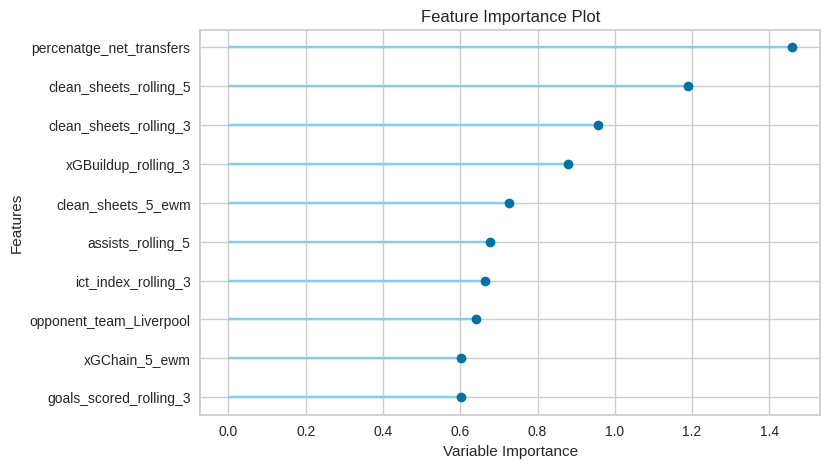

In [34]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 11)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model = base_model.compare_models(sort='MAE', n_select=1)
print(best_model)

evaluate_model(best_model)

plot_model(best_model, plot='feature')        # Feature importance


## GW 12


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1377, 342)"
4,Transformed data shape,"(1377, 128)"
5,Transformed train set shape,"(1101, 128)"
6,Transformed test set shape,"(276, 128)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7069,0.8939,0.9446,0.7514,0.2386,0.3465,1.7850
gbr,Gradient Boosting Regressor,0.7291,0.9548,0.9764,0.7335,0.2447,0.3628,1.0900
et,Extra Trees Regressor,0.7394,0.9832,0.9903,0.7267,0.2526,0.3865,1.3460
ridge,Ridge Regression,0.7415,0.9905,0.9939,0.7238,0.2498,0.3544,0.3440
xgboost,Extreme Gradient Boosting,0.7538,1.0263,1.0108,0.7161,0.2523,0.3654,0.9860
rf,Random Forest Regressor,0.7593,1.0213,1.0094,0.7163,0.2573,0.3956,2.2120
lr,Linear Regression,0.7822,1.1109,1.0530,0.6899,0.2697,0.3788,0.4130
ada,AdaBoost Regressor,0.8592,1.2111,1.0990,0.6627,0.2889,0.4980,0.6470
en,Elastic Net,0.9848,1.6069,1.2656,0.5502,0.3195,0.5142,0.4120
lasso,Lasso Regression,1.0440,1.7767,1.3310,0.5026,0.3346,0.5486,0.3730


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

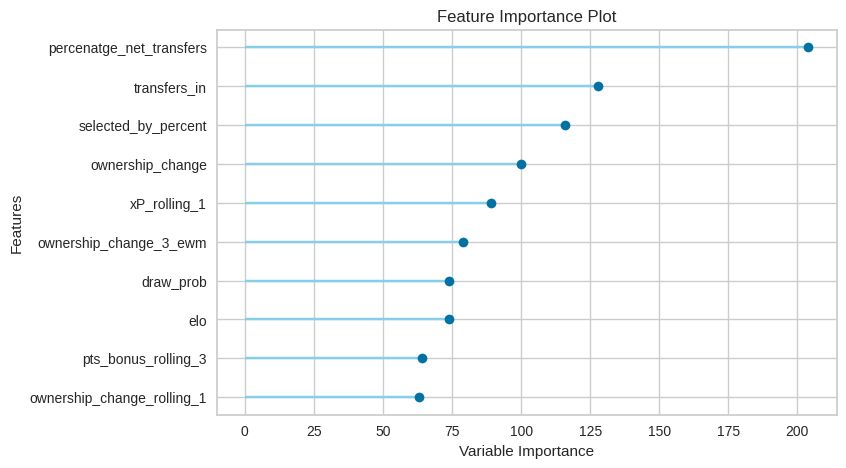

In [35]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 12)
base_model_12 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_12 = base_model_12.compare_models(sort='MAE', n_select=1)
print(best_model_12)

evaluate_model(best_model_12)

plot_model(best_model_12, plot='feature')        # Feature importance


## GW 13


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1597, 342)"
4,Transformed data shape,"(1597, 126)"
5,Transformed train set shape,"(1277, 126)"
6,Transformed test set shape,"(320, 126)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7418,1.0028,0.9993,0.7230,0.2494,0.3640,1.6100
gbr,Gradient Boosting Regressor,0.7625,1.0494,1.0211,0.7094,0.2538,0.3793,1.4020
xgboost,Extreme Gradient Boosting,0.7904,1.1418,1.0650,0.6807,0.2587,0.3754,1.2930
et,Extra Trees Regressor,0.7933,1.1327,1.0596,0.6872,0.2631,0.4025,1.6550
ridge,Ridge Regression,0.8045,1.1086,1.0515,0.6899,0.2669,0.3780,0.3410
rf,Random Forest Regressor,0.8163,1.1967,1.0902,0.6692,0.2699,0.4120,2.7820
lr,Linear Regression,0.8400,1.2489,1.1147,0.6495,0.2834,0.3920,0.3290
ada,AdaBoost Regressor,0.9850,1.4908,1.2184,0.5869,0.3207,0.5787,0.6800
en,Elastic Net,1.0267,1.7342,1.3131,0.5243,0.3293,0.5245,0.3520
lasso,Lasso Regression,1.0891,1.9117,1.3787,0.4772,0.3444,0.5601,0.3660


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

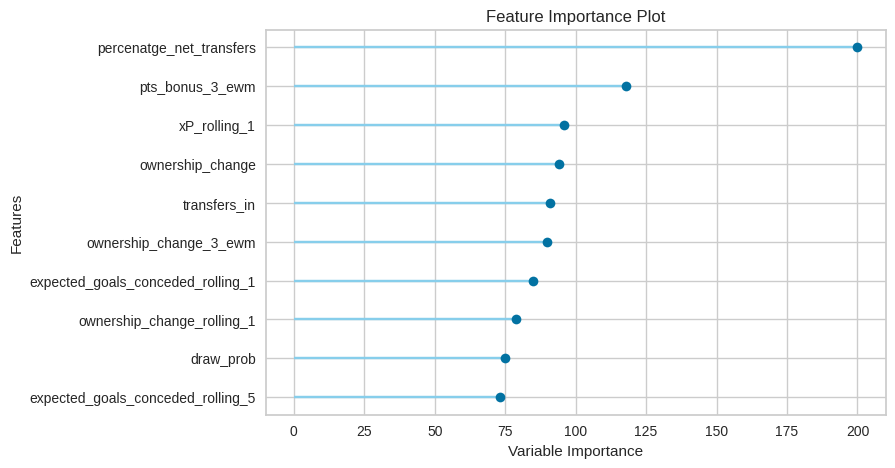

In [36]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 13)
base_model_13 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_13 = base_model_13.compare_models(sort='MAE', n_select=1)
print(best_model_13)

evaluate_model(best_model_13)

plot_model(best_model_13, plot='feature')        # Feature importance


## GW 14


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1811, 342)"
4,Transformed data shape,"(1811, 125)"
5,Transformed train set shape,"(1448, 125)"
6,Transformed test set shape,"(363, 125)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7283,0.9458,0.9686,0.7454,0.2391,0.3453,1.6770
gbr,Gradient Boosting Regressor,0.7442,0.9778,0.9841,0.7370,0.2466,0.3592,1.2710
ridge,Ridge Regression,0.7626,1.0091,1.0018,0.7255,0.2505,0.3534,0.3760
et,Extra Trees Regressor,0.7683,1.0750,1.0331,0.7098,0.2576,0.3855,1.6230
xgboost,Extreme Gradient Boosting,0.7839,1.0847,1.0378,0.7066,0.2581,0.3762,1.1080
rf,Random Forest Regressor,0.8064,1.1777,1.0816,0.6820,0.2674,0.4032,2.8930
lr,Linear Regression,0.8329,1.2059,1.0917,0.6730,0.2737,0.3846,0.4220
ada,AdaBoost Regressor,0.9044,1.3141,1.1425,0.6438,0.2971,0.5110,0.7260
en,Elastic Net,0.9858,1.6052,1.2638,0.5670,0.3179,0.5059,0.3900
lasso,Lasso Regression,1.0670,1.8303,1.3497,0.5067,0.3379,0.5505,0.3800


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

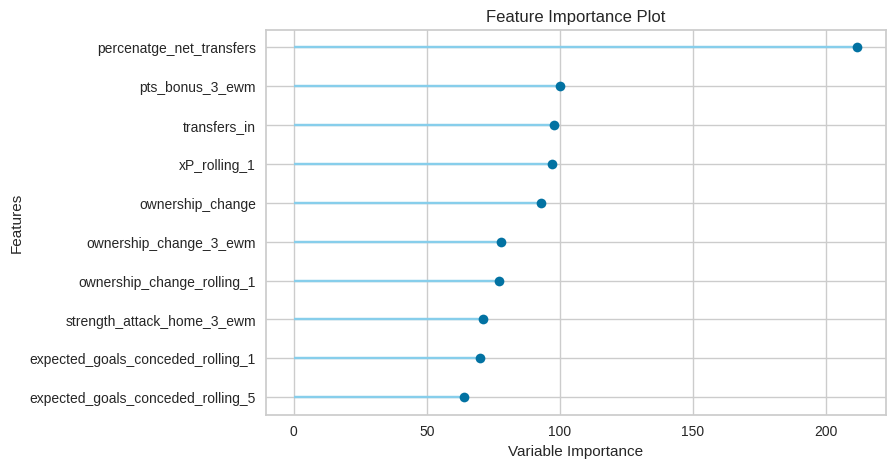

In [37]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 14)
base_model_14 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_14 = base_model_14.compare_models(sort='MAE', n_select=1)
print(best_model_14)

evaluate_model(best_model_14)

plot_model(best_model_14, plot='feature')        # Feature importance


## GW 15


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(2047, 342)"
4,Transformed data shape,"(2047, 125)"
5,Transformed train set shape,"(1637, 125)"
6,Transformed test set shape,"(410, 125)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7104,0.9207,0.9580,0.7526,0.2362,0.3546,1.1610
gbr,Gradient Boosting Regressor,0.7378,0.9886,0.9924,0.7354,0.2470,0.3710,1.2190
xgboost,Extreme Gradient Boosting,0.7547,1.0235,1.0103,0.7239,0.2476,0.3659,0.8790
et,Extra Trees Regressor,0.7614,1.0528,1.0239,0.7188,0.2556,0.3982,1.9610
ridge,Ridge Regression,0.7617,1.0178,1.0077,0.7267,0.2500,0.3663,0.4630
rf,Random Forest Regressor,0.7872,1.1134,1.0526,0.7027,0.2623,0.4093,3.3210
lr,Linear Regression,0.8056,1.1365,1.0650,0.6930,0.2641,0.3863,0.4110
ada,AdaBoost Regressor,0.9304,1.3662,1.1673,0.6342,0.3091,0.5592,0.7910
en,Elastic Net,0.9856,1.6176,1.2701,0.5672,0.3176,0.5192,0.4090
lasso,Lasso Regression,1.0826,1.8980,1.3758,0.4921,0.3428,0.5733,0.4360


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

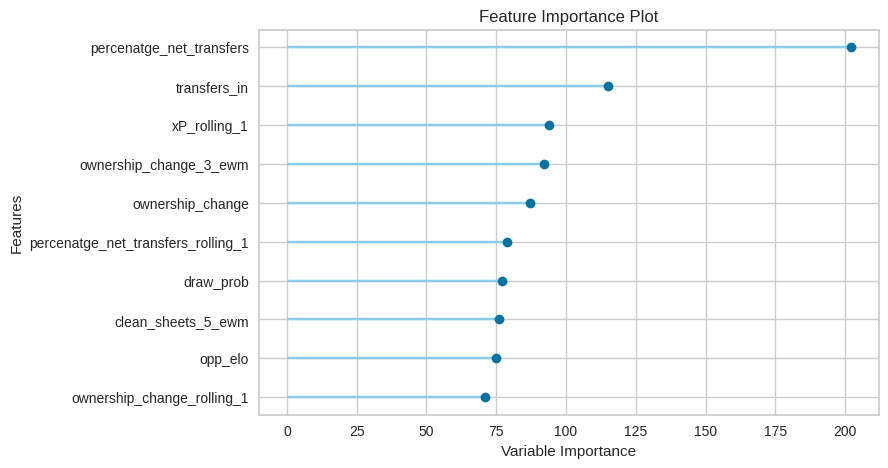

In [38]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 15)
base_model_15 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_15 = base_model_15.compare_models(sort='MAE', n_select=1)
print(best_model_15)

evaluate_model(best_model_15)

plot_model(best_model_15, plot='feature')        # Feature importance


## GW 16


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(2277, 342)"
4,Transformed data shape,"(2277, 127)"
5,Transformed train set shape,"(1821, 127)"
6,Transformed test set shape,"(456, 127)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7177,0.9553,0.9725,0.7427,0.2318,0.3223,1.1730
gbr,Gradient Boosting Regressor,0.7361,0.9924,0.9918,0.7318,0.2399,0.3400,1.3510
et,Extra Trees Regressor,0.7444,1.0115,1.0008,0.7276,0.2478,0.3606,1.7430
ridge,Ridge Regression,0.7451,0.9815,0.9846,0.7322,0.2426,0.3318,0.3570
xgboost,Extreme Gradient Boosting,0.7604,1.0869,1.0380,0.7077,0.2495,0.3453,0.9020
rf,Random Forest Regressor,0.7825,1.0958,1.0411,0.7053,0.2557,0.3756,3.1050
lr,Linear Regression,0.7897,1.0880,1.0384,0.7034,0.2590,0.3589,0.3680
ada,AdaBoost Regressor,0.9169,1.3416,1.1550,0.6351,0.3030,0.5177,0.6830
en,Elastic Net,0.9680,1.5622,1.2441,0.5764,0.3102,0.4814,0.3750
lasso,Lasso Regression,1.0592,1.8323,1.3488,0.5019,0.3350,0.5303,0.3700


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

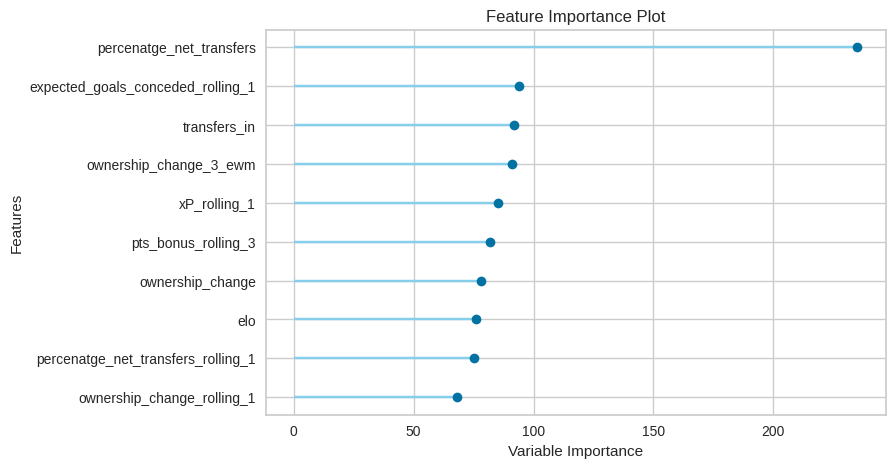

In [39]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 16)
base_model_16 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_16 = base_model_16.compare_models(sort='MAE', n_select=1)
print(best_model_16)

evaluate_model(best_model_16)

plot_model(best_model_16, plot='feature')        # Feature importance


## GW \_


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

try:
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
except ImportError:
    print("Ensure xgboost and lightgbm are installed to use the full tournament.")


In [41]:
class GameweekTournament:
    def __init__(self, df, candidate_features, target='target_points'):
        self.df = df
        self.features = candidate_features
        self.target = target
        self.history = []

    def evaluate_models(self, train_df, val_df):
        """
        Tests the specified model architectures on the current data slice.
        """
        X_train_raw = train_df[self.features]
        y_train = train_df[self.target]
        X_val_raw = val_df[self.features]
        y_val = val_df[self.target]

        # Scaling for linear-based models
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw)
        X_val_scaled = scaler.transform(X_val_raw)

        # The expanded list of models for the tournament
        models = {
            'Ridge': Ridge(alpha=1.0),
            'LinearReg': LinearRegression(),
            'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42),
            'ExtraTrees': ExtraTreesRegressor(n_estimators=50, random_state=42),
            'GradientBoosting': GradientBoostingRegressor(n_estimators=50, random_state=42),
            'XGBoost': XGBRegressor(n_estimators=50, random_state=42),
            'LightGBM': LGBMRegressor(n_estimators=50, random_state=42, verbose=-1)
        }

        scores = {}
        linear_types = ['Ridge', 'LinearReg']

        for name, model in models.items():
            # Use scaled data for linear types, raw for Tree/Boosting types
            X_t = X_train_scaled if name in linear_types else X_train_raw
            X_v = X_val_scaled if name in linear_types else X_val_raw

            try:
                model.fit(X_t, y_train)
                preds = model.predict(X_v)
                scores[name] = mean_absolute_error(y_val, preds)
            except Exception as e:
                print(f"Skipping {name} due to error: {e}")

        return scores

    def get_best_features_for_model(self, model_name, train_df):
        """
        Performs feature selection specific to the winning model architecture.
        """
        X = train_df[self.features]
        y = train_df[self.target]
        linear_types = ['Ridge', 'LinearReg']

        if model_name in linear_types:
            # Use RFE with the winning linear model
            base_model = Ridge() if model_name == 'Ridge' else LinearRegression()
            selector = RFE(base_model, n_features_to_select=10)
            selector.fit(StandardScaler().fit_transform(X), y)
            return [f for f, s in zip(self.features, selector.support_) if s]

        else:
            # Tree-based selection using feature_importances_
            if model_name == 'RandomForest':
                m = RandomForestRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'ExtraTrees':
                m = ExtraTreesRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'GradientBoosting':
                m = GradientBoostingRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'XGBoost':
                m = XGBRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'LightGBM':
                m = LGBMRegressor(n_estimators=50, verbose=-1).fit(X, y)

            importances = pd.Series(m.feature_importances_, index=self.features)
            return importances.sort_values(ascending=False).head(10).index.tolist()

    def run_season_simulation(self, start_gw=5):
        """
        Main loop: Benchmarks all 7 models and selects features for every round.
        """
        max_gw = self.df['round'].max()

        for gw in range(start_gw, max_gw + 1):
            # Split data: Training (historical), Val (last week), Test (current week)
            train_data = self.df[self.df['round'] < (gw - 1)]
            val_data = self.df[self.df['round'] == (gw - 1)]
            test_data = self.df[self.df['round'] == gw]

            if val_data.empty or train_data.empty: continue

            # 1. Performance Test to find this week's "Best Model"
            scores = self.evaluate_models(train_data, val_data)
            best_model_name = min(scores, key=scores.get)

            # 2. Extract best features using the winner's logic
            best_features = self.get_best_features_for_model(best_model_name, train_data)

            # 3. Final Retrain on all available data up to the test GW
            final_train = self.df[self.df['round'] < gw]
            X_final = final_train[best_features]
            y_final = final_train[self.target]

            # Re-instantiate the winner
            if best_model_name == 'Ridge':
                m_final = Ridge()
            elif best_model_name == 'LinearReg':
                m_final = LinearRegression()
            elif best_model_name == 'RandomForest':
                m_final = RandomForestRegressor(n_estimators=50)
            elif best_model_name == 'ExtraTrees':
                m_final = ExtraTreesRegressor(n_estimators=50)
            elif best_model_name == 'GradientBoosting':
                m_final = GradientBoostingRegressor(n_estimators=50)
            elif best_model_name == 'XGBoost':
                m_final = XGBRegressor(n_estimators=50)
            elif best_model_name == 'LightGBM':
                m_final = LGBMRegressor(n_estimators=50, verbose=-1)

            # Execution
            linear_types = ['Ridge', 'LinearReg']
            if best_model_name in linear_types:
                sc = StandardScaler()
                X_f = sc.fit_transform(X_final)
                X_test = sc.transform(test_data[best_features])
                m_final.fit(X_f, y_final)
            else:
                m_final.fit(X_final, y_final)
                X_test = test_data[best_features]

            mae = mean_absolute_error(test_data[self.target], m_final.predict(X_test))

            self.history.append({
                'GW': gw,
                'BestModel': best_model_name,
                'MAE': mae,
                'TopFeature': best_features[0]
            })
            print(f"GW {gw} Winner: {best_model_name} | MAE: {mae:.4f}")

        return pd.DataFrame(self.history)

def plot_tournament_results(results_df):
    plt.figure(figsize=(14, 7))

    # Plot global error trend
    plt.plot(results_df['GW'], results_df['MAE'], marker='o', color='gray', alpha=0.3, label='MAE Trend')

    # Distinct colors for each model architecture
    palette = {
        'Ridge': '#1f77b4', 'LinearReg': '#aec7e8',
        'RandomForest': '#2ca02c', 'ExtraTrees': '#98df8a',
        'GradientBoosting': '#ff7f0e', 'XGBoost': '#d62728',
        'LightGBM': '#9467bd'
    }

    for model_name, group in results_df.groupby('BestModel'):
        plt.scatter(group['GW'], group['MAE'], color=palette.get(model_name, 'black'),
                    label=f'Winner: {model_name}', s=120, edgecolors='white', zorder=5)

    plt.title('7-Model FPL Tournament: Weekly Model Selection Results', fontsize=14)
    plt.xlabel('Gameweek', fontsize=12)
    plt.ylabel('Mean Absolute Error (Lower is Better)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

## Feature Importance


In [42]:

def select_best_features(df, features):
    """
    Ranks features using LightGBM feature importance.
    Tree models naturally calculate which features reduce variance the most.
    """
    reliable_df = df[df['round'] >= 6].copy()

    X = reliable_df[features]
    y = reliable_df['xP']

    # Use default params for ranking
    model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    model.fit(X, y)

    importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Add a 'Rank' column to match the previous structure
    importances['Rank'] = range(1, len(importances) + 1)
    return importances

def run_reliability_test(df, selected_features):
    """
    Simulates the season using only the selected features.
    """
    gws = sorted(df['round'].unique())
    results = []
    test_start_gw = 7
    scaler = StandardScaler()

    # Range of alpha values to test
    # alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
    # Hyperparameters to tune: Learning Rate and Complexity (num_leaves)
    learning_rates = [0.01, 0.05, 0.1]
    num_leaves_list = [15, 31, 63]
    best_gw_mae = float('inf')
    # best_n = 1
    # best_alpha = 1.0
    best_learning_rate = 1.0
    best_num_leaves = 10

    best_gw_mae = float('inf')
    # best_n = 1
    best_lr = 0.1
    best_leaves = 31

    # 3. Grid Search: Feature Count x Learning Rate x Leaves
    search_limit = min(len(selected_features), 12)

    # for current_gw in range(test_start_gw, max(gws) + 1):
    train_df = df[df['round'] < round]
    test_df = df[df['round'] == round]

    X_train = scaler.fit_transform(train_df[selected_features])
    X_test = scaler.transform(test_df[selected_features])

    # model = Ridge(alpha=1.0)
    # model.fit(X_train, train_df['xP'])

    for lr in learning_rates:
        for leaves in num_leaves_list:
            val_model = LGBMRegressor(
                learning_rate=lr,
                num_leaves=leaves,
                n_estimators=100,
                random_state=42,
                verbose=-1
            )
        # val_model = Ridge(alpha=a, random_state=42)
            val_model.fit(X_train, train_df['xP'])
            v_mae = mean_absolute_error(test_df['xP'], val_model.predict(X_test))

            if v_mae < best_gw_mae:
                best_gw_mae = v_mae
                # best_n = n
                best_lr = lr
                best_leaves = leaves

    results.append({'GW': round, 'MAE': best_gw_mae, 'lr': best_lr, 'leaves': best_leaves})

    return pd.DataFrame(results)


In [43]:
feature_ranks = select_best_features(data[data['round'] < 16],  feature_cols)
feature_ranks

,Feature,Importance,Rank
6,percenatge_net_transfers,183,1
38,xP_rolling_1,68,2
168,pts_bonus_3_ewm,64,3
2,transfers_in,59,4
5,ownership_change,59,5
...,...,...,...
242,ownership_change_1_ewm,0,336
239,transfers_out_1_ewm,0,337
236,transfers_in_1_ewm,0,338
233,selected_1_ewm,0,339


In [44]:
# --- Execution ---
def get_gw_best_features(data, round):
    print(f"Step 1: Ranking Features for GW {round} using Recursive Feature Elimination...")

    feature_ranks = select_best_features(data[data['round'] < round],  feature_cols)

    # # Step 2: Automated Selection
    print(f"\nStep 2: Finding Optimal Feature Cut-off. of the {len(feature_cols)} features..")

    # We iterate through the top N features to find where MAE stops improving
    best_overall_mae = float('inf')
    best_overall_lr = 1
    best_overall_leaves = 31
    optimal_count = 1

    # Testing up to top 10 (or however many you want to check)
    search_limit = min(len(feature_cols), 50)


    for i in range(1, search_limit + 1):
        trial_features = feature_ranks.head(i)['Feature'].tolist()
        reliability_df = run_reliability_test(data[data['round']<= round], trial_features)


        avg_mae = reliability_df['MAE'].mean()
        avg_lr = reliability_df['lr'].mean()
        avg_leaves = reliability_df['leaves'].mean()


        print(f"Testing top {i} features: Average MAE = {avg_mae:.4f}")

        if avg_mae < best_overall_mae:
            best_overall_mae = avg_mae
            best_overall_lr = avg_lr
            best_overall_leaves = avg_leaves
            optimal_count = i


    # Final Prediction for the actual Deadline
    train_df = data[data['round'] < round]
    test_df = data[data['round'] == round]

    chosen_features = feature_ranks.head(optimal_count)['Feature'].tolist()

    final_model = LGBMRegressor(
        learning_rate=best_overall_lr,
        num_leaves=np.int64(best_overall_leaves),
        n_estimators=100,
        random_state=42,
        verbose=-1
    )
    print(best_overall_leaves, best_overall_lr)
    final_model.fit(train_df[chosen_features], train_df['xP'])
    actual_mae = mean_absolute_error(test_df['xP'], final_model.predict(test_df[chosen_features]))

    print(f"GW {round}: Used {len(chosen_features)} features. MAE: {actual_mae:.4f}")
    print(f"\nOptimal number of features: {optimal_count}")
    print(f"Selected Features: {round}==> {chosen_features}")

    return chosen_features, optimal_count, actual_mae, best_overall_lr, best_overall_leaves



In [45]:
selected_features = {}
for round in range(8,24):
    selected_features[round] = get_gw_best_features(data, round)


Step 1: Ranking Features for GW 8 using Recursive Feature Elimination...

Step 2: Finding Optimal Feature Cut-off. of the 340 features..
Testing top 1 features: Average MAE = 1.1678
Testing top 2 features: Average MAE = 1.0909
Testing top 3 features: Average MAE = 0.9714
Testing top 4 features: Average MAE = 0.9551
Testing top 5 features: Average MAE = 0.9210
Testing top 6 features: Average MAE = 0.8913
Testing top 7 features: Average MAE = 0.9262
Testing top 8 features: Average MAE = 0.9321
Testing top 9 features: Average MAE = 0.9108
Testing top 10 features: Average MAE = 0.8835
Testing top 11 features: Average MAE = 0.8820
Testing top 12 features: Average MAE = 0.8794
Testing top 13 features: Average MAE = 0.9033
Testing top 14 features: Average MAE = 0.8876
Testing top 15 features: Average MAE = 0.8789
Testing top 16 features: Average MAE = 0.8593
Testing top 17 features: Average MAE = 0.8689
Testing top 18 features: Average MAE = 0.8850
Testing top 19 features: Average MAE = 0.883

In [46]:
selections = pd.DataFrame(selected_features).T
selections.columns = ['best_features', 'optimal_count', 'best_overall_mae', 'best_lr', 'best_leaves']
selections

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves
8,"[percenatge_net_transfers, transfers_in, pts_b...",32,0.844301,0.1,31.0
9,"[percenatge_net_transfers, transfers_in, owner...",47,0.739452,0.1,15.0
10,"[percenatge_net_transfers, transfers_in, owner...",49,0.751067,0.1,15.0
11,"[percenatge_net_transfers, transfers_in, owner...",33,0.851061,0.05,31.0
12,"[percenatge_net_transfers, transfers_in, owner...",12,0.979615,0.1,63.0
13,"[percenatge_net_transfers, ownership_change, p...",34,0.798859,0.1,15.0
14,"[percenatge_net_transfers, transfers_in, xP_ro...",43,0.667274,0.05,15.0
15,"[percenatge_net_transfers, transfers_in, owner...",33,0.665388,0.05,15.0
16,"[percenatge_net_transfers, xP_rolling_1, pts_b...",47,0.700192,0.05,15.0
17,"[percenatge_net_transfers, xP_rolling_1, pts_b...",10,0.658128,0.05,15.0


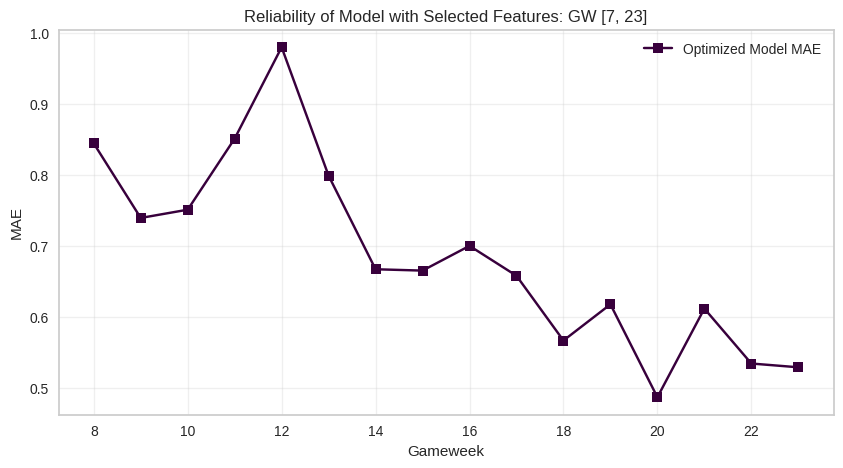

In [47]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections.index, selections['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [7, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [48]:
110+21+25+35+15+15+40+24+1.4+7+45+1.8+20

360.2

### AffinePNN


#### GW8


Data prepared. X shape: (4291, 31), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100


2026-01-31 22:10:21.295741: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.6673 - mae: 0.3600 - mse: 0.1640 - val_loss: 0.6651 - val_mae: 0.3676 - val_mse: 0.1642 - learning_rate: 1.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6437 - mae: 0.3339 - mse: 0.1445 - val_loss: 0.6494 - val_mae: 0.3525 - val_mse: 0.1526 - learning_rate: 1.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6175 - mae: 0.3022 - mse: 0.1225 - val_loss: 0.6329 - val_mae: 0.3357 - val_mse: 0.1402 - learning_rate: 1.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6008 - mae: 0.2821 - mse: 0.1100 - val_loss: 0.6159 - val_mae: 0.3176 - val_mse: 0.1275 - learning_rate: 1.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5777 - mae: 0.2552 - mse: 0.0911 - val_loss: 0.5990 - val_mae: 0.2992 - val_mse: 0.1148 - learning_rate: 1.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5600 - mae: 0.2290 - mse: 0.0778 - val_loss: 0.5824 - val_ma

2026-01-31 22:10:50.873176: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


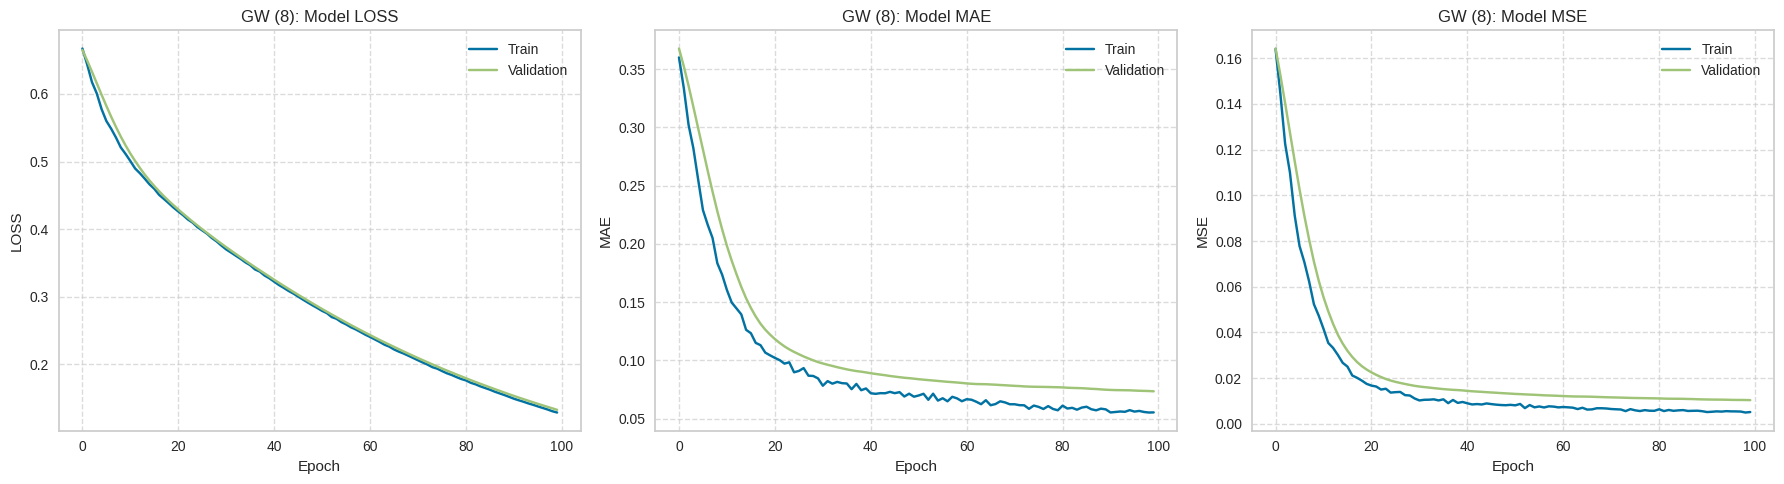

Data prepared. X shape: (4291, 45), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.6862 - mae: 0.3748 - mse: 0.1805 - val_loss: 0.6316 - val_mae: 0.3100 - val_mse: 0.1296 - learning_rate: 1.0000e-04
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6511 - mae: 0.3394 - mse: 0.1520 - val_loss: 0.6143 - val_mae: 0.2953 - val_mse: 0.1187 - learning_rate: 1.0000e-04
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6161 - mae: 0.3008 - mse: 0.1232 - val_loss: 0.5955 - val_mae: 0.2781 - val_mse: 0.1062 - learning_rate: 1.0000e-04
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5893 - mae: 0.2710 - mse: 0.1029 - val_loss: 0.5760 - val_mae: 0.2588 - val_mse: 0.0931 - learning_rate: 1.0000e-04
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5601 - mae: 0.2361 - mse: 0.0803 - val_loss: 0.5565 - val_mae: 0.2384 - val_mse: 0.0802 - learning_rate: 1.0000e-04
Epoch 6/100
18/1

2026-01-31 22:11:19.203539: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


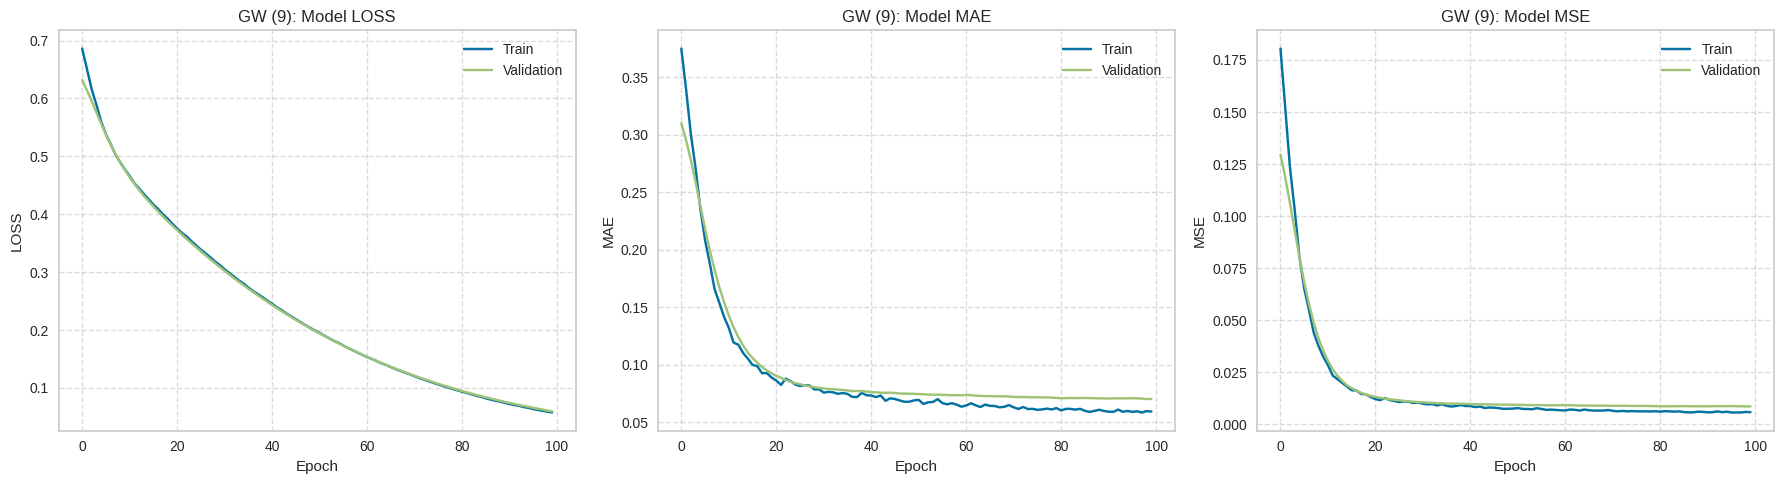

Data prepared. X shape: (4291, 48), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.6027 - mae: 0.2529 - mse: 0.0925 - val_loss: 0.6082 - val_mae: 0.2694 - val_mse: 0.1028 - learning_rate: 1.0000e-04
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5673 - mae: 0.2101 - mse: 0.0663 - val_loss: 0.5802 - val_mae: 0.2422 - val_mse: 0.0842 - learning_rate: 1.0000e-04
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5407 - mae: 0.1772 - mse: 0.0495 - val_loss: 0.5532 - val_mae: 0.2147 - val_mse: 0.0672 - learning_rate: 1.0000e-04
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5176 - mae: 0.1481 - mse: 0.0364 - val_loss: 0.5285 - val_mae: 0.1883 - val_mse: 0.0527 - learning_rate: 1.0000e-04
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5011 - mae: 0.1369 - mse: 0.0303 - val_loss: 0.5063 - val_mae: 0.1642 - val_mse: 0.0410 - learning_rate: 1.0000e-04
Epoch 6/100
23/

2026-01-31 22:11:52.335306: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


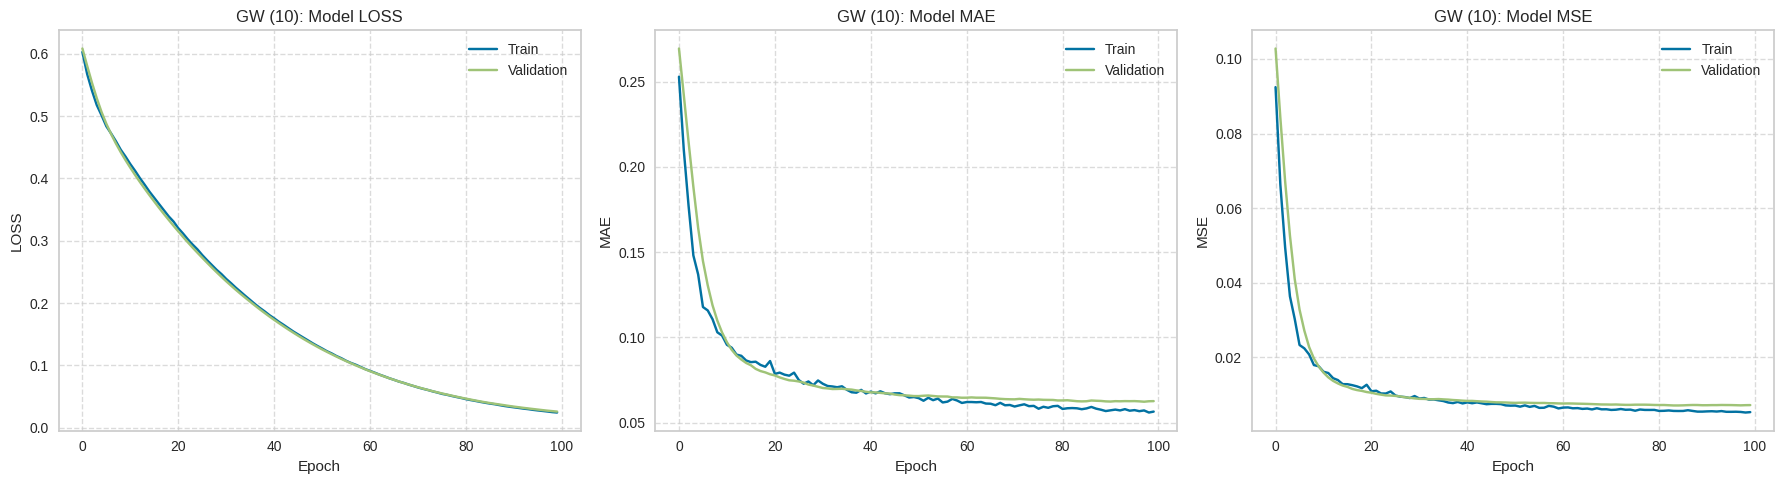

Data prepared. X shape: (4291, 32), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.5852 - mae: 0.2519 - mse: 0.0902 - val_loss: 0.5777 - val_mae: 0.2535 - val_mse: 0.0883 - learning_rate: 1.0000e-04
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5435 - mae: 0.1971 - mse: 0.0596 - val_loss: 0.5481 - val_mae: 0.2248 - val_mse: 0.0703 - learning_rate: 1.0000e-04
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5119 - mae: 0.1584 - mse: 0.0400 - val_loss: 0.5200 - val_mae: 0.1963 - val_mse: 0.0546 - learning_rate: 1.0000e-04
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4903 - mae: 0.1374 - mse: 0.0312 - val_loss: 0.4940 - val_mae: 0.1698 - val_mse: 0.0416 - learning_rate: 1.0000e-04
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4702 - mae: 0.1192 - mse: 0.0242 - val_loss: 0.4713 - val_mae: 0.1485 - val_mse: 0.0322 - learning_rate: 1.0000e-04
Epoch 6/100
29/2

2026-01-31 22:12:30.826555: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


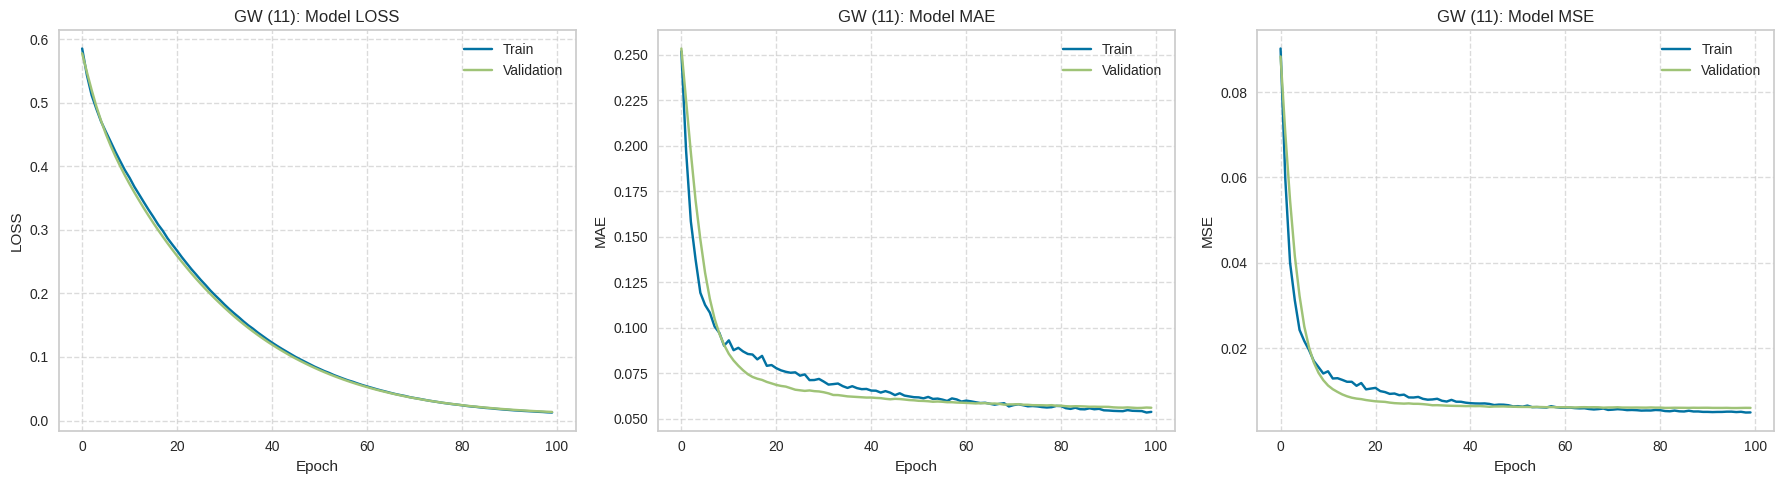

Data prepared. X shape: (4291, 11), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4897 - mae: 0.1372 - mse: 0.0292 - val_loss: 0.4722 - val_mae: 0.1201 - val_mse: 0.0206 - learning_rate: 1.0000e-04
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4616 - mae: 0.1058 - mse: 0.0186 - val_loss: 0.4504 - val_mae: 0.1083 - val_mse: 0.0169 - learning_rate: 1.0000e-04
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4396 - mae: 0.0929 - mse: 0.0150 - val_loss: 0.4296 - val_mae: 0.1014 - val_mse: 0.0148 - learning_rate: 1.0000e-04
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4191 - mae: 0.0880 - mse: 0.0131 - val_loss: 0.4096 - val_mae: 0.0956 - val_mse: 0.0132 - learning_rate: 1.0000e-04
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4001 - mae: 0.0849 - mse: 0.0123 - val_loss: 0.3904 - val_mae: 0.0904 - val_mse: 0.0120 - learning_rate: 1.0000e-04
Epoch 6/100
35/3

2026-01-31 22:13:11.418467: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


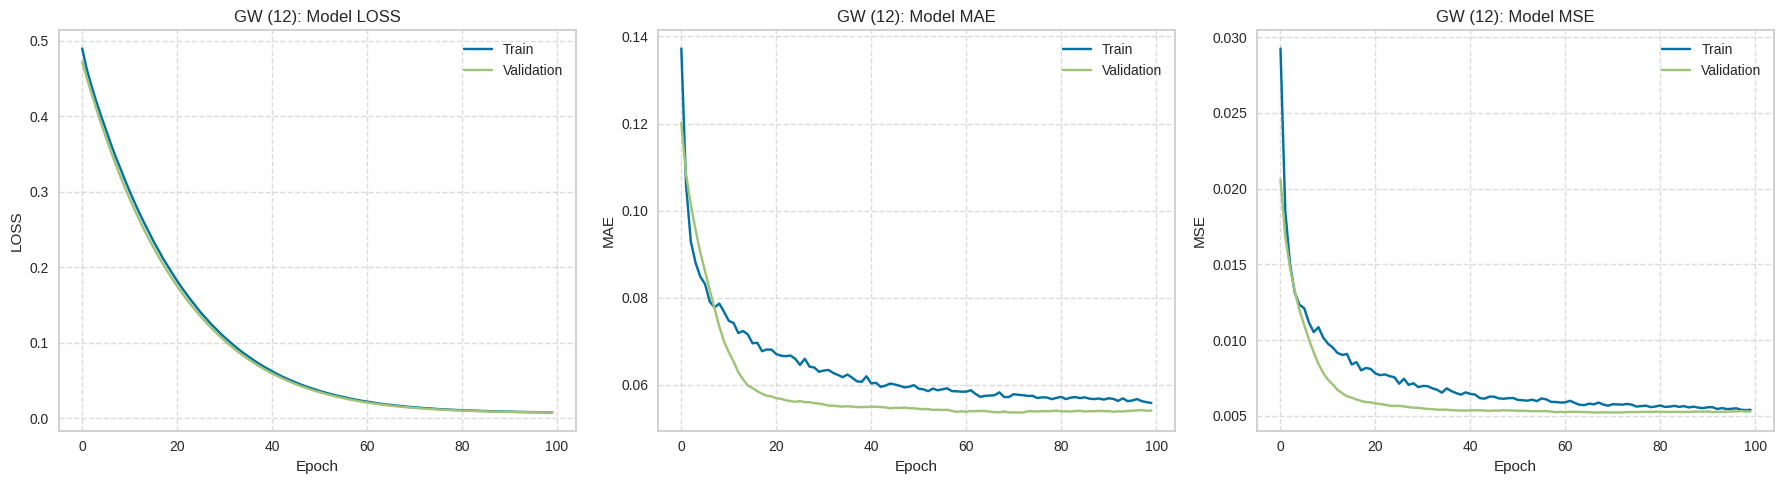

Data prepared. X shape: (4291, 33), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.6190 - mae: 0.2843 - mse: 0.1107 - val_loss: 0.6251 - val_mae: 0.3282 - val_mse: 0.1254 - learning_rate: 1.0000e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5581 - mae: 0.2093 - mse: 0.0667 - val_loss: 0.5683 - val_mae: 0.2637 - val_mse: 0.0859 - learning_rate: 1.0000e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5165 - mae: 0.1637 - mse: 0.0426 - val_loss: 0.5203 - val_mae: 0.2045 - val_mse: 0.0556 - learning_rate: 1.0000e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4855 - mae: 0.1357 - mse: 0.0295 - val_loss: 0.4825 - val_mae: 0.1585 - val_mse: 0.0359 - learning_rate: 1.0000e-04
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4593 - mae: 0.1151 - mse: 0.0216 - val_loss: 0.4526 - val_mae: 0.1265 - val_mse: 0.0243 - learning_rate: 1.0000e-04
Epoch 6/100
40/4

2026-01-31 22:13:52.266277: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


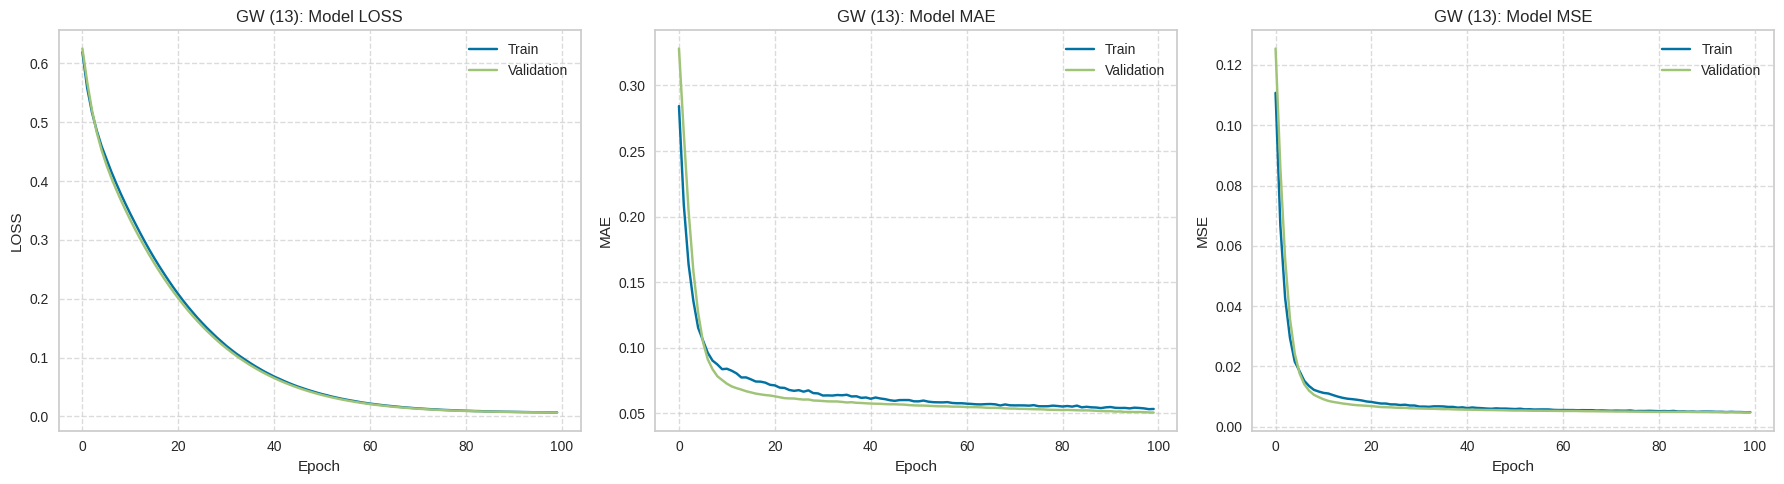

Data prepared. X shape: (4291, 41), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
32/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5942 - mae: 0.1819 - mse: 0.0536

2026-01-31 22:13:57.313644: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5777 - mae: 0.1654 - mse: 0.0448 - val_loss: 0.5425 - val_mae: 0.1175 - val_mse: 0.0224 - learning_rate: 1.0000e-04
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5350 - mae: 0.1282 - mse: 0.0271 - val_loss: 0.5104 - val_mae: 0.0981 - val_mse: 0.0156 - learning_rate: 1.0000e-04
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5029 - mae: 0.1126 - mse: 0.0204 - val_loss: 0.4814 - val_mae: 0.0857 - val_mse: 0.0120 - learning_rate: 1.0000e-04
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4742 - mae: 0.1010 - mse: 0.0168 - val_loss: 0.4545 - val_mae: 0.0779 - val_mse: 0.0101 - learning_rate: 1.0000e-04
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4473 - mae: 0.0947 - mse: 0.0146 - val_loss: 0.4290 - val_mae: 0.0724 - val_mse: 0.0088 - learning_rate: 1.0000e-04
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4229 - mae: 0.0924 - mse: 0.0141 - val_loss: 0.4049 - val_mae: 

2026-01-31 22:14:42.016928: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


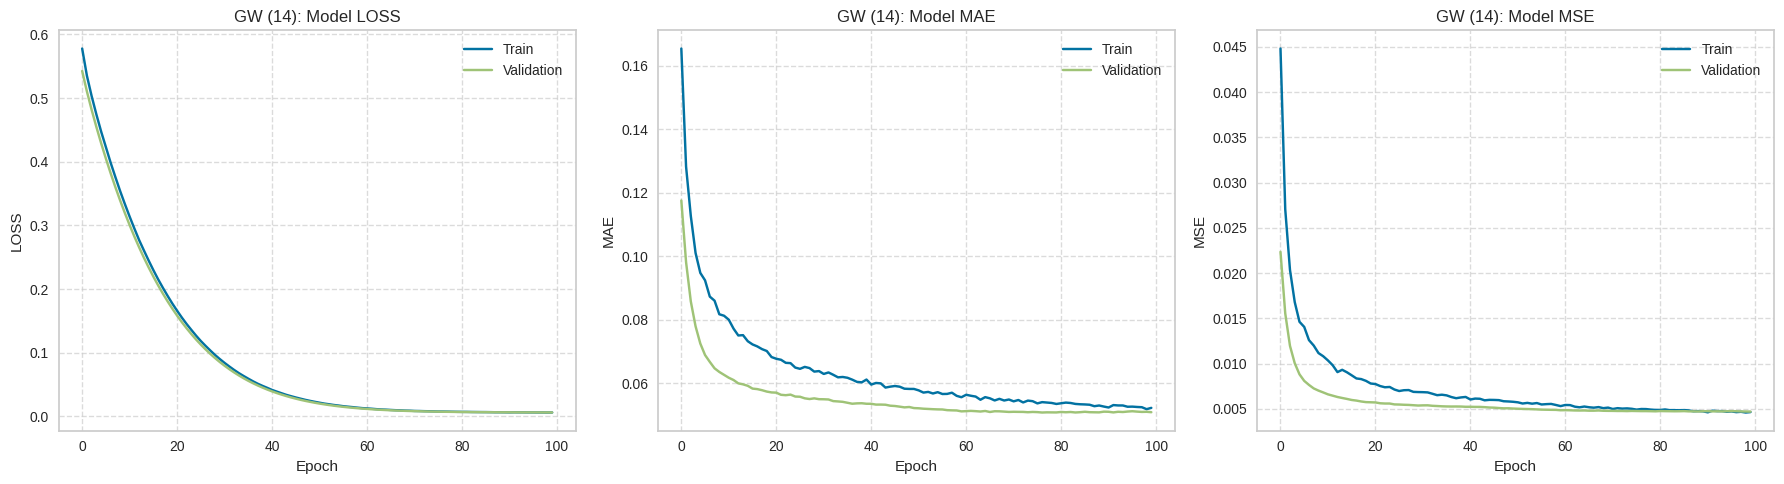

Data prepared. X shape: (4291, 32), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5653 - mae: 0.1763 - mse: 0.0506 - val_loss: 0.5534 - val_mae: 0.1827 - val_mse: 0.0514 - learning_rate: 1.0000e-04
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5162 - mae: 0.1278 - mse: 0.0266 - val_loss: 0.5051 - val_mae: 0.1362 - val_mse: 0.0293 - learning_rate: 1.0000e-04
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4820 - mae: 0.1067 - mse: 0.0192 - val_loss: 0.4681 - val_mae: 0.1096 - val_mse: 0.0191 - learning_rate: 1.0000e-04
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4528 - mae: 0.0987 - mse: 0.0167 - val_loss: 0.4368 - val_mae: 0.0940 - val_mse: 0.0143 - learning_rate: 1.0000e-04
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4252 - mae: 0.0943 - mse: 0.0151 - val_loss: 0.4087 - val_mae: 0.0850 - val_mse: 0.0118 - learning_rate: 1.0000e-04
Epoch 6/100
52/

2026-01-31 22:15:37.717146: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


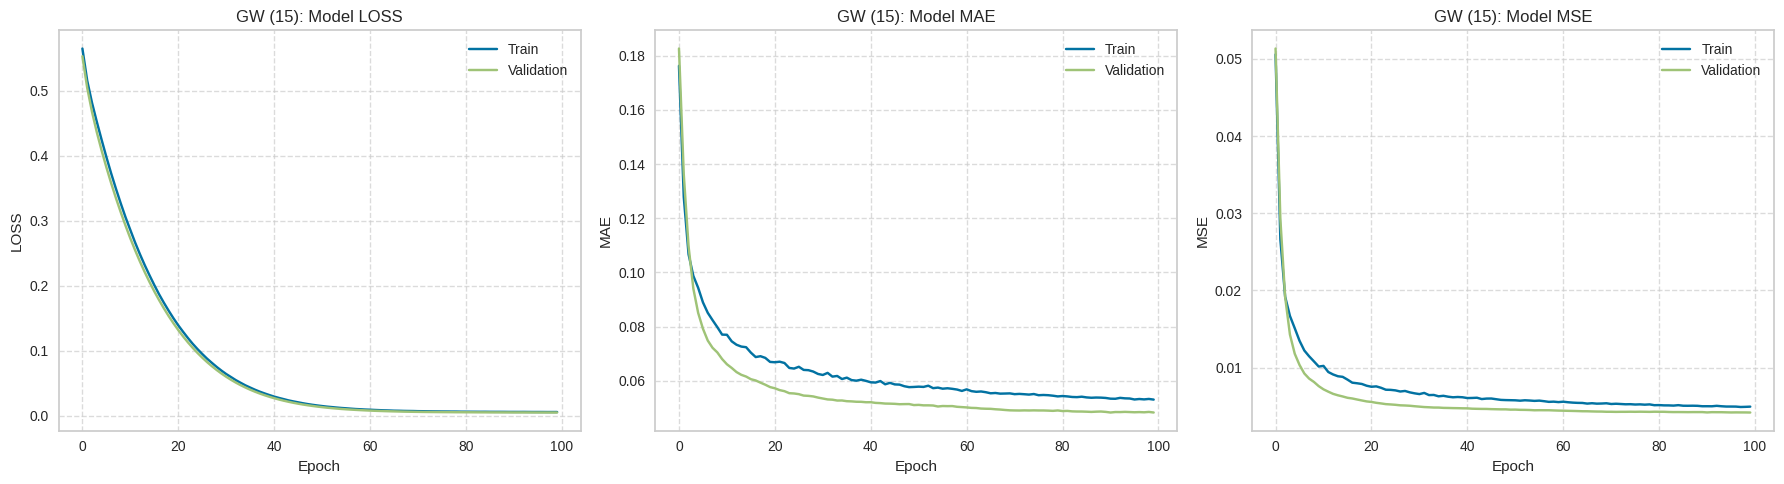

Data prepared. X shape: (4291, 45), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5764 - mae: 0.1593 - mse: 0.0379

2026-01-31 22:15:43.180203: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5614 - mae: 0.1397 - mse: 0.0305 - val_loss: 0.5376 - val_mae: 0.1251 - val_mse: 0.0223 - learning_rate: 1.0000e-04
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5165 - mae: 0.1013 - mse: 0.0172 - val_loss: 0.4964 - val_mae: 0.0945 - val_mse: 0.0137 - learning_rate: 1.0000e-04
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4812 - mae: 0.0916 - mse: 0.0145 - val_loss: 0.4610 - val_mae: 0.0818 - val_mse: 0.0107 - learning_rate: 1.0000e-04
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4480 - mae: 0.0862 - mse: 0.0131 - val_loss: 0.4285 - val_mae: 0.0757 - val_mse: 0.0093 - learning_rate: 1.0000e-04
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4164 - mae: 0.0821 - mse: 0.0119 - val_loss: 0.3983 - val_mae: 0.0727 - val_mse: 0.0087 - learning_rate: 1.0000e-04
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3870 - mae: 0.0801 - mse: 0.0112 - val_loss: 0.3698 - val_mae: 

2026-01-31 22:16:29.408281: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


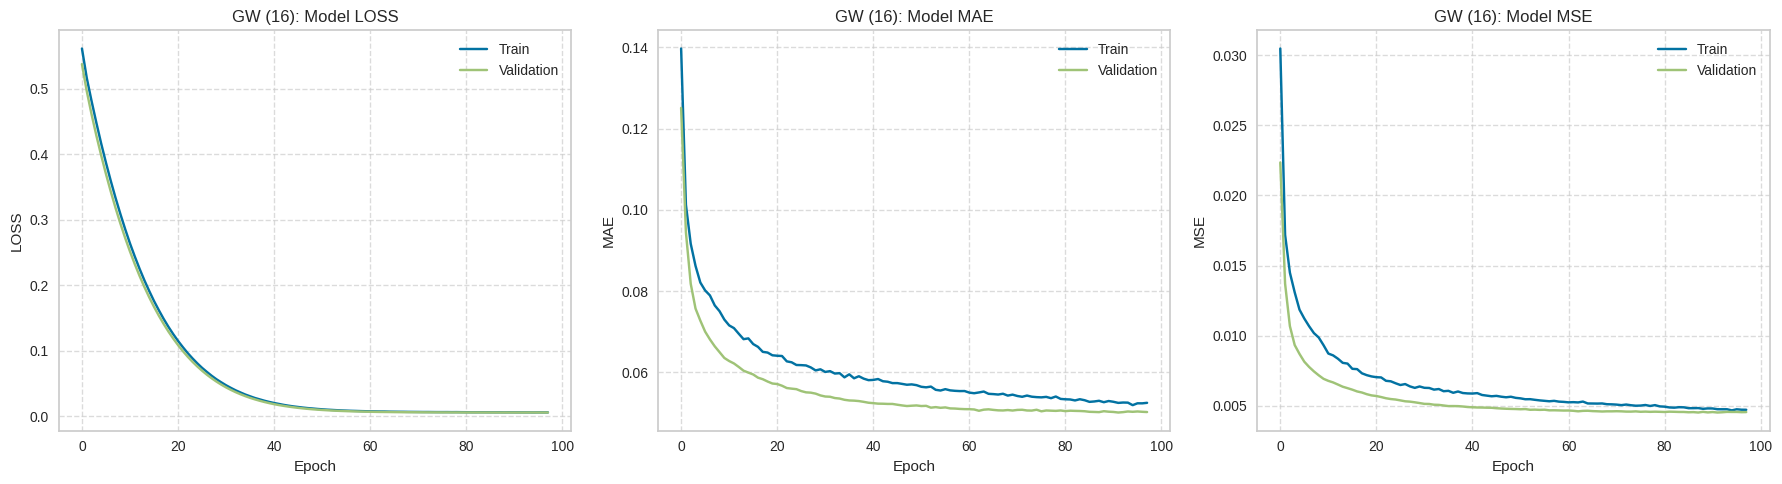

Data prepared. X shape: (4291, 9), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6026 - mae: 0.3372 - mse: 0.1427 - val_loss: 0.5670 - val_mae: 0.3240 - val_mse: 0.1179 - learning_rate: 1.0000e-04
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4999 - mae: 0.2141 - mse: 0.0616 - val_loss: 0.4942 - val_mae: 0.2408 - val_mse: 0.0675 - learning_rate: 1.0000e-04
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4436 - mae: 0.1393 - mse: 0.0288 - val_loss: 0.4393 - val_mae: 0.1724 - val_mse: 0.0371 - learning_rate: 1.0000e-04
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4074 - mae: 0.1053 - mse: 0.0176 - val_loss: 0.3980 - val_mae: 0.1239 - val_mse: 0.0210 - learning_rate: 1.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3782 - mae: 0.0910 - mse: 0.0135 - val_loss: 0.3647 - val_mae: 0.0912 - val_mse: 0.0127 - learning_rate: 1.0000e-04
Epoch 6/100
62/62 ━

2026-01-31 22:17:20.484212: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


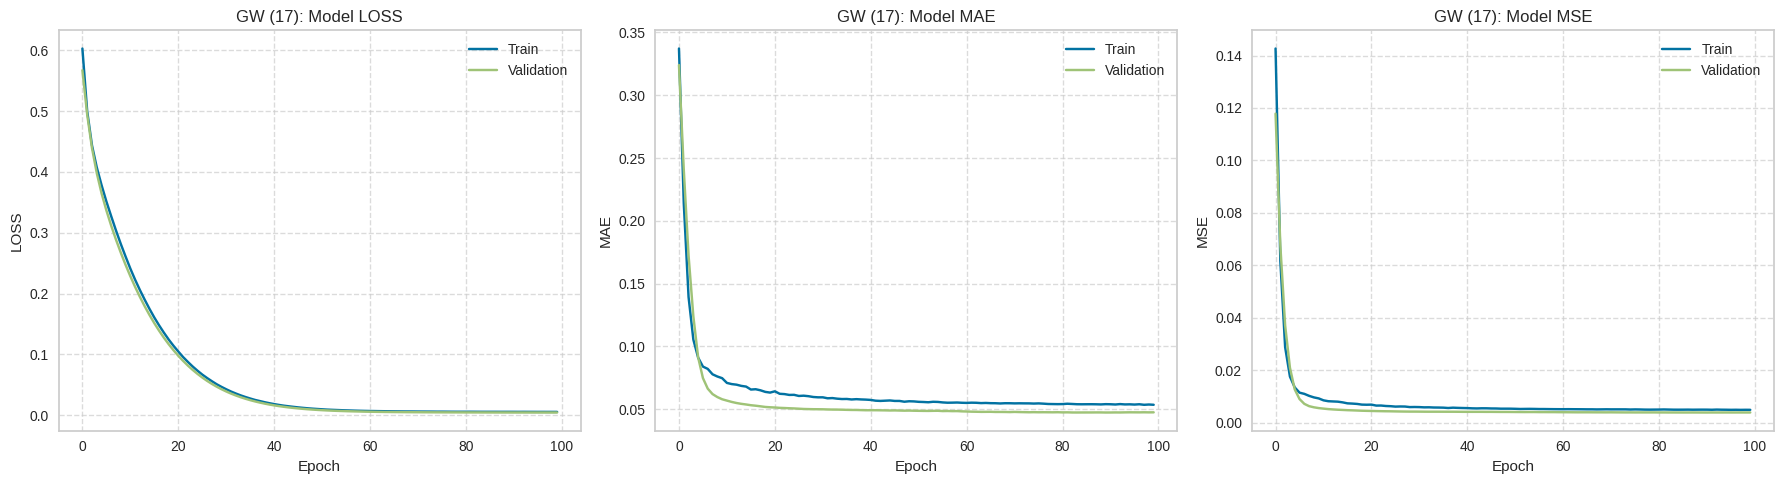

Data prepared. X shape: (4291, 34), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5730 - mae: 0.1815 - mse: 0.0537 - val_loss: 0.5543 - val_mae: 0.1945 - val_mse: 0.0516 - learning_rate: 1.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5113 - mae: 0.1230 - mse: 0.0256 - val_loss: 0.4949 - val_mae: 0.1387 - val_mse: 0.0269 - learning_rate: 1.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4677 - mae: 0.1014 - mse: 0.0170 - val_loss: 0.4494 - val_mae: 0.1057 - val_mse: 0.0164 - learning_rate: 1.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4304 - mae: 0.0917 - mse: 0.0142 - val_loss: 0.4108 - val_mae: 0.0868 - val_mse: 0.0116 - learning_rate: 1.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3956 - mae: 0.0854 - mse: 0.0123 - val_loss: 0.3767 - val_mae: 0.0776 - val_mse: 0.0095 - learning_rate: 1.0000e-04
Epoch 6/100
67/67 

2026-01-31 22:18:06.208026: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


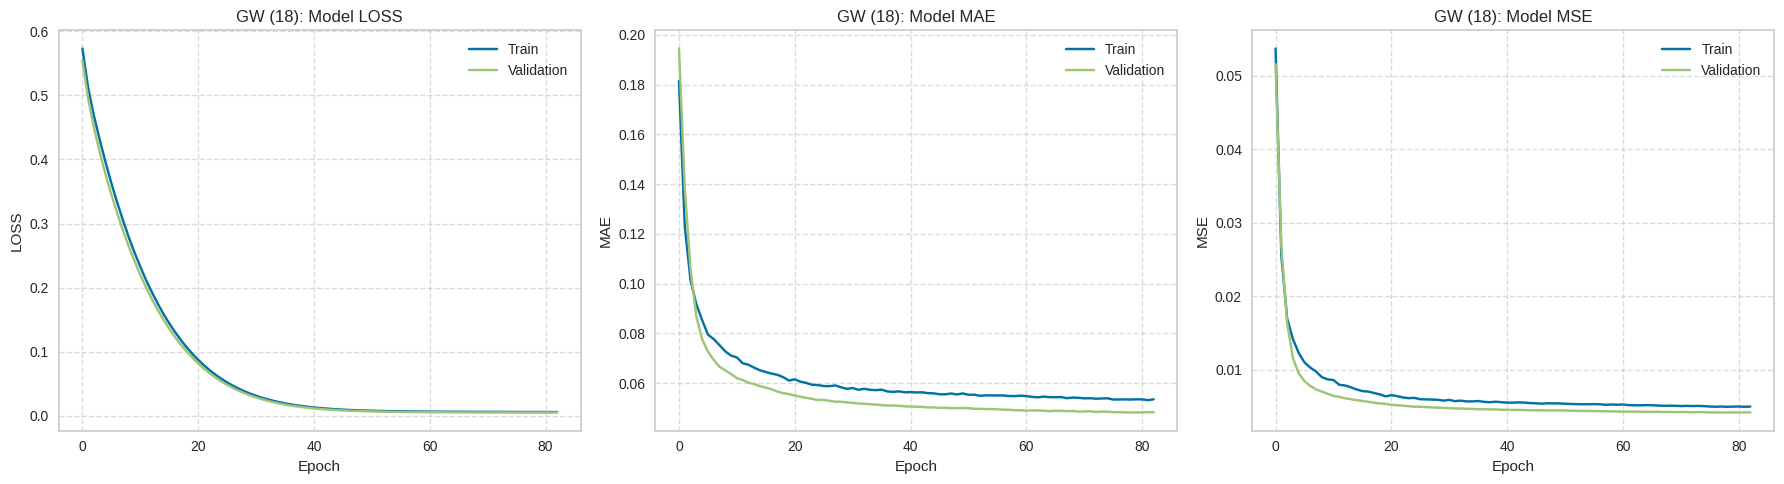

Data prepared. X shape: (4291, 45), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5866 - mae: 0.2073 - mse: 0.0618 - val_loss: 0.5608 - val_mae: 0.2001 - val_mse: 0.0535 - learning_rate: 1.0000e-04
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5167 - mae: 0.1290 - mse: 0.0276 - val_loss: 0.4935 - val_mae: 0.1265 - val_mse: 0.0235 - learning_rate: 1.0000e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4706 - mae: 0.1049 - mse: 0.0190 - val_loss: 0.4462 - val_mae: 0.0930 - val_mse: 0.0136 - learning_rate: 1.0000e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4298 - mae: 0.0931 - mse: 0.0151 - val_loss: 0.4067 - val_mae: 0.0793 - val_mse: 0.0102 - learning_rate: 1.0000e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3922 - mae: 0.0861 - mse: 0.0127 - val_loss: 0.3711 - val_mae: 0.0729 - val_mse: 0.0087 - learning_rate: 1.0000e-04
Epoch 6/100
73/73 

2026-01-31 22:18:58.829342: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


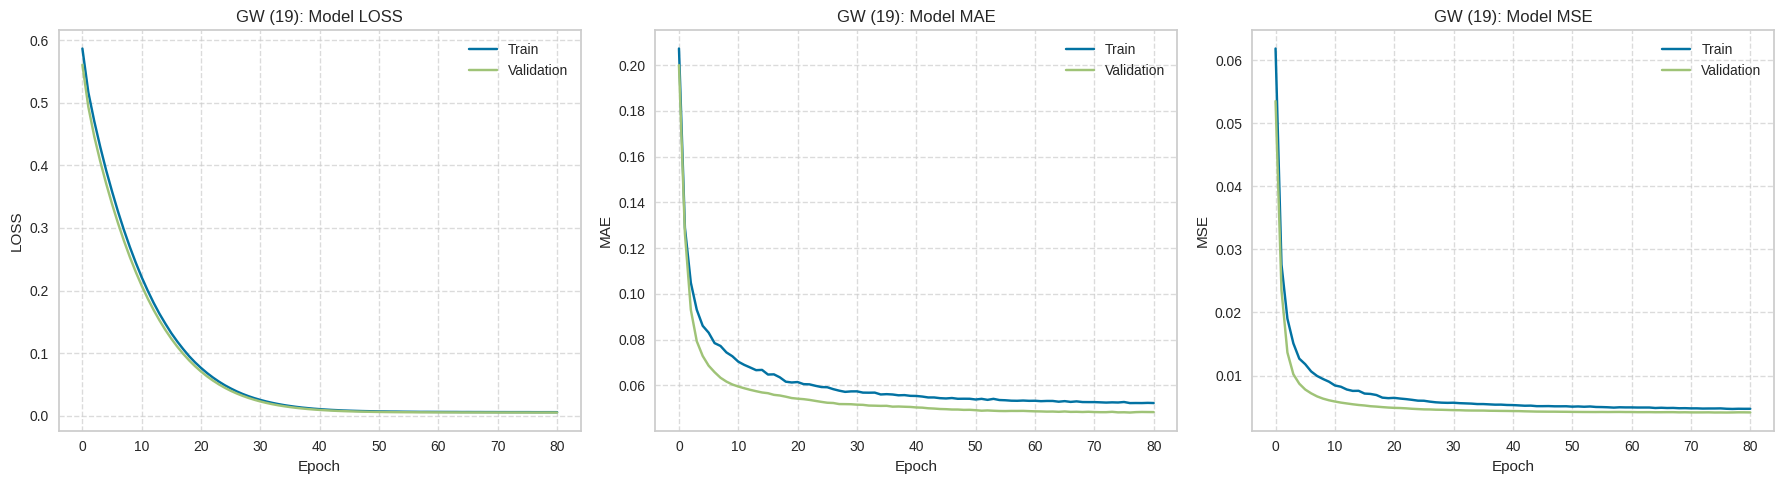

Data prepared. X shape: (4291, 44), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
71/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6494 - mae: 0.2623 - mse: 0.1033

2026-01-31 22:19:03.871805: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6168 - mae: 0.2232 - mse: 0.0795 - val_loss: 0.6077 - val_mae: 0.2509 - val_mse: 0.0879 - learning_rate: 1.0000e-04
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5351 - mae: 0.1378 - mse: 0.0334 - val_loss: 0.5199 - val_mae: 0.1511 - val_mse: 0.0371 - learning_rate: 1.0000e-04
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4846 - mae: 0.1095 - mse: 0.0204 - val_loss: 0.4646 - val_mae: 0.1053 - val_mse: 0.0193 - learning_rate: 1.0000e-04
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4436 - mae: 0.0979 - mse: 0.0163 - val_loss: 0.4220 - val_mae: 0.0865 - val_mse: 0.0131 - learning_rate: 1.0000e-04
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4053 - mae: 0.0899 - mse: 0.0135 - val_loss: 0.3848 - val_mae: 0.0780 - val_mse: 0.0104 - learning_rate: 1.0000e-04
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3702 - mae: 0.0857 - mse: 0.0121 - val_loss: 0.3508 - val_mae: 0.0

2026-01-31 22:19:49.848719: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


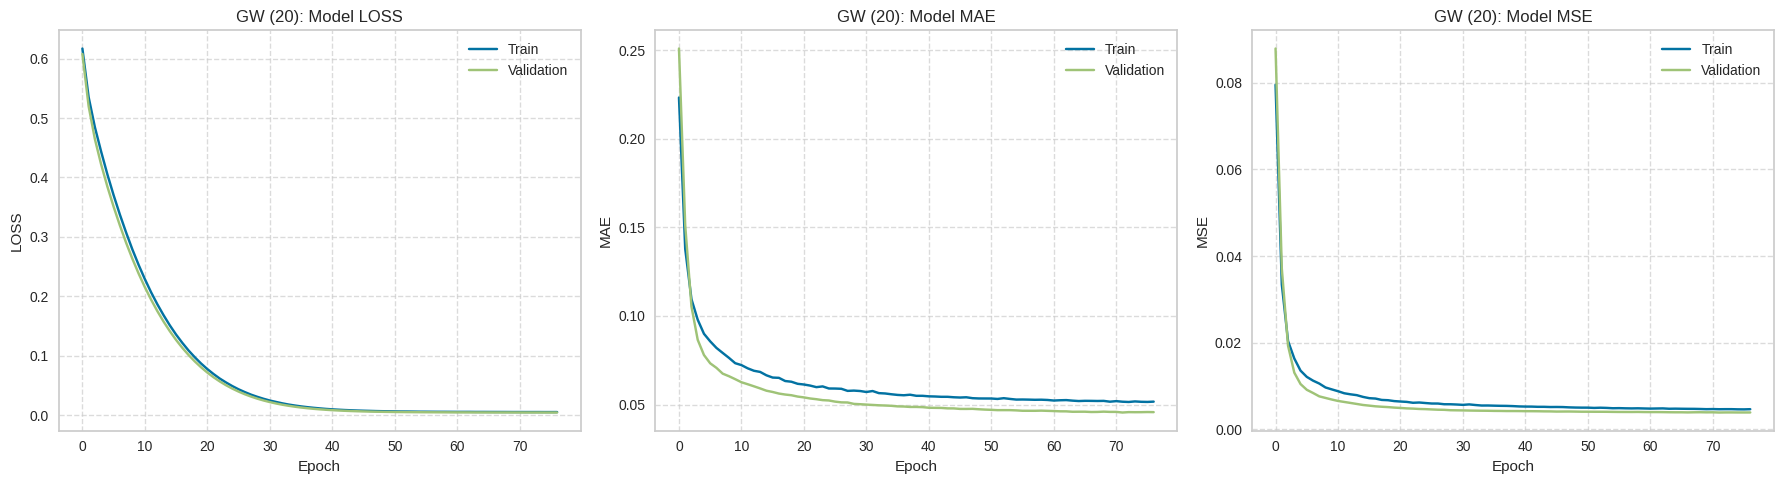

Data prepared. X shape: (4291, 43), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5660 - mae: 0.1668 - mse: 0.0463 - val_loss: 0.5419 - val_mae: 0.1655 - val_mse: 0.0447 - learning_rate: 1.0000e-04
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4963 - mae: 0.1137 - mse: 0.0216 - val_loss: 0.4735 - val_mae: 0.1182 - val_mse: 0.0222 - learning_rate: 1.0000e-04
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4441 - mae: 0.0948 - mse: 0.0148 - val_loss: 0.4205 - val_mae: 0.0925 - val_mse: 0.0137 - learning_rate: 1.0000e-04
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3979 - mae: 0.0847 - mse: 0.0119 - val_loss: 0.3751 - val_mae: 0.0791 - val_mse: 0.0101 - learning_rate: 1.0000e-04
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3563 - mae: 0.0796 - mse: 0.0106 - val_loss: 0.3347 - val_mae: 0.0712 - val_mse: 0.0083 - learning_rate: 1.0000e-04
Epoch 6/100
84/84 

2026-01-31 22:20:39.303303: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


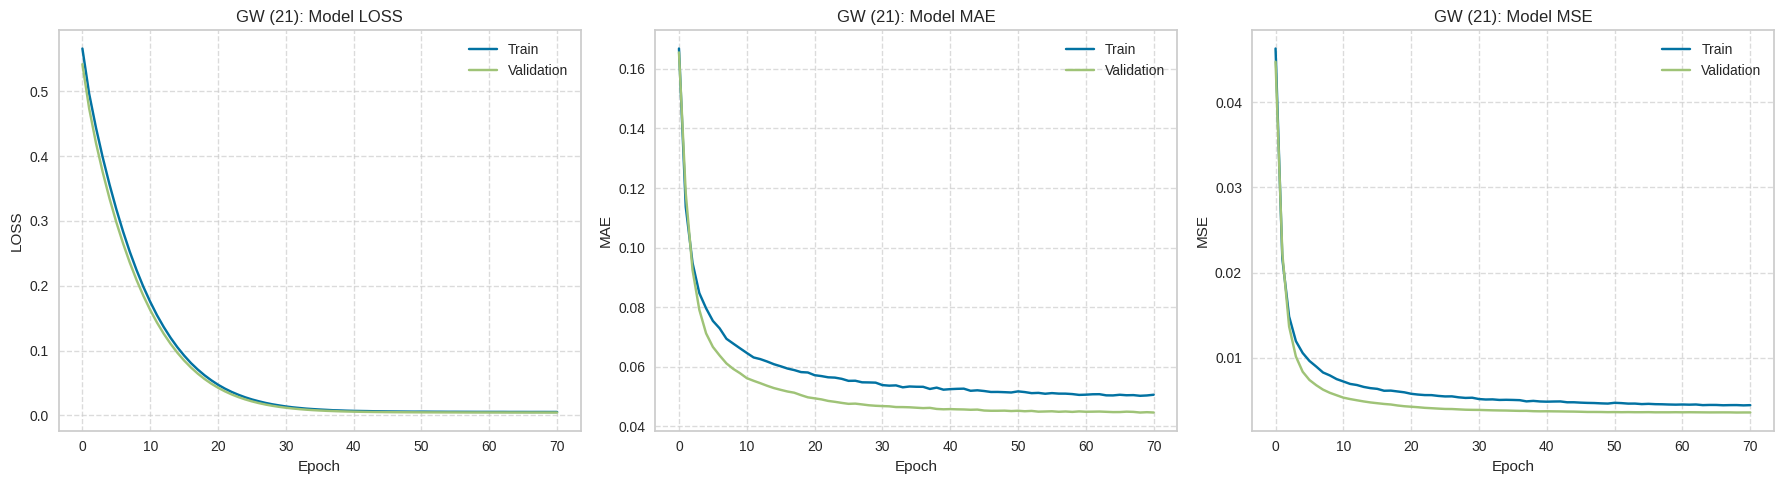

Data prepared. X shape: (4291, 30), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5758 - mae: 0.2064 - mse: 0.0636 - val_loss: 0.5415 - val_mae: 0.1888 - val_mse: 0.0500 - learning_rate: 1.0000e-04
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4939 - mae: 0.1174 - mse: 0.0235 - val_loss: 0.4686 - val_mae: 0.1154 - val_mse: 0.0207 - learning_rate: 1.0000e-04
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4418 - mae: 0.0942 - mse: 0.0152 - val_loss: 0.4167 - val_mae: 0.0857 - val_mse: 0.0121 - learning_rate: 1.0000e-04
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3967 - mae: 0.0860 - mse: 0.0125 - val_loss: 0.3727 - val_mae: 0.0741 - val_mse: 0.0092 - learning_rate: 1.0000e-04
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3551 - mae: 0.0794 - mse: 0.0107 - val_loss: 0.3332 - val_mae: 0.0688 - val_mse: 0.0080 - learning_rate: 1.0000e-04
Epoch 6/100
90/90 

2026-01-31 22:21:37.160481: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


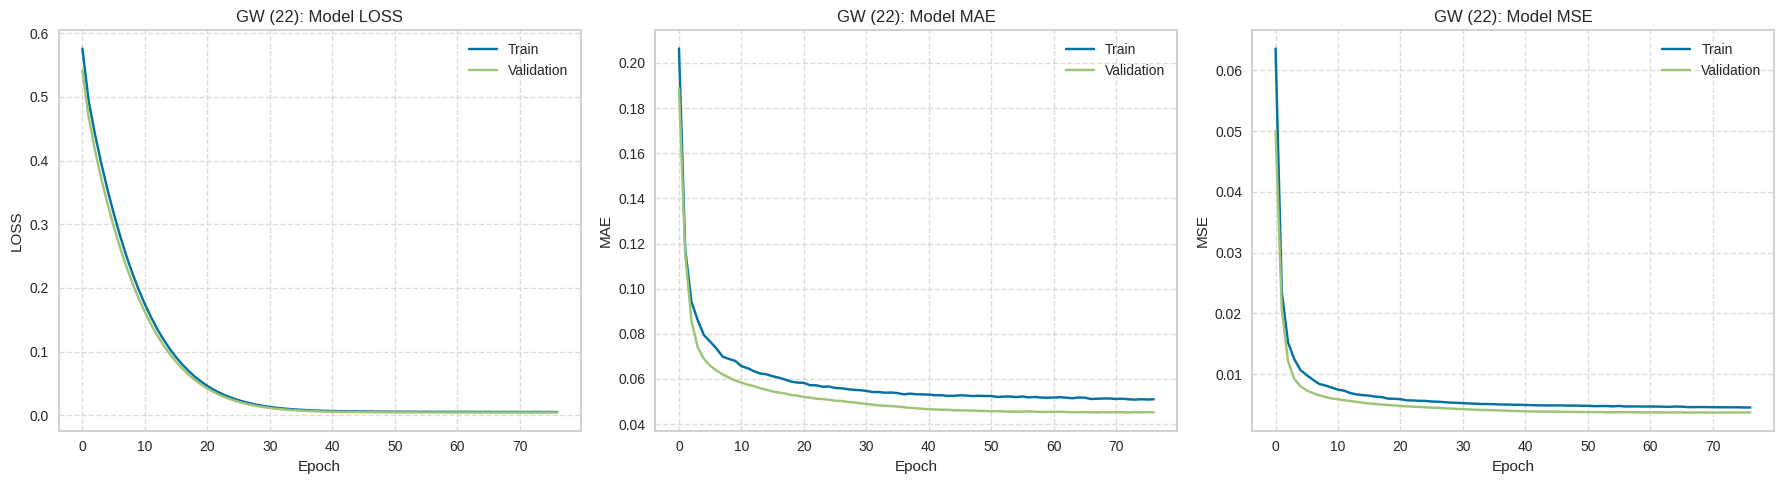

Data prepared. X shape: (4291, 43), M shape: (4291, 8), Y shape: (4291, 2)

Starting Training...
Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5612 - mae: 0.1440 - mse: 0.0340 - val_loss: 0.5228 - val_mae: 0.1278 - val_mse: 0.0230 - learning_rate: 1.0000e-04
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4908 - mae: 0.1015 - mse: 0.0181 - val_loss: 0.4564 - val_mae: 0.0869 - val_mse: 0.0113 - learning_rate: 1.0000e-04
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4333 - mae: 0.0885 - mse: 0.0138 - val_loss: 0.4021 - val_mae: 0.0722 - val_mse: 0.0082 - learning_rate: 1.0000e-04
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3818 - mae: 0.0809 - mse: 0.0114 - val_loss: 0.3542 - val_mae: 0.0668 - val_mse: 0.0073 - learning_rate: 1.0000e-04
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3361 - mae: 0.0774 - mse: 0.0104 - val_loss: 0.3111 - val_mae: 0.0626 - val_mse: 0.0065 - learning_rate: 1.0000e-04
Epoch 6/100
95/95 

2026-01-31 22:22:20.563406: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


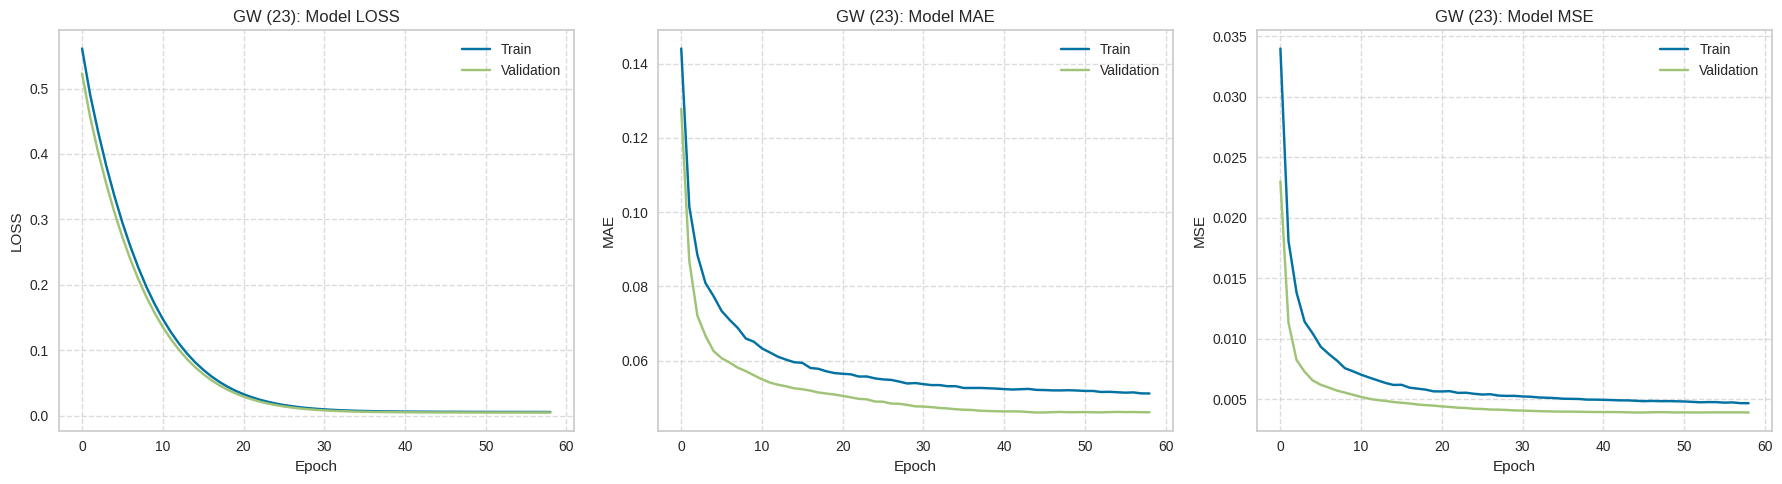

In [78]:
eval_metrics = {}
preds = {}
for round in range(8,24):
    history, evaluation_metrics, preds_df, _ = apnn_trainer(data, selections.loc[round, 'best_features'], round)
    preds[round] = preds_df
    eval_metrics[round] = evaluation_metrics

    # Plot History
    plot_training_history(history, round)


In [84]:
eval_metrics_=pd.DataFrame(eval_metrics).T

In [ ]:

# EVALUATE TEST SET PERFORMANCE
print(f"\n--- Final Test Set Evaluation (GW {8}) ---")
print(f"R²: {evaluation_metrics_8['test_R2']:.5f}")
print(f"MAE: {evaluation_metrics_8['test_mae']:.5f}")
print(f"MSE: {evaluation_metrics_8['test_mse']:.5f}")
print(f"Loss: {evaluation_metrics_8['test_loss']:.5f}")

print("\n--- Results for Gameweek 8 ---")
preds_df_8.sort_values(by='Predicted_xP', ascending=False)#.#head(10).round(2).to_string(index=False))


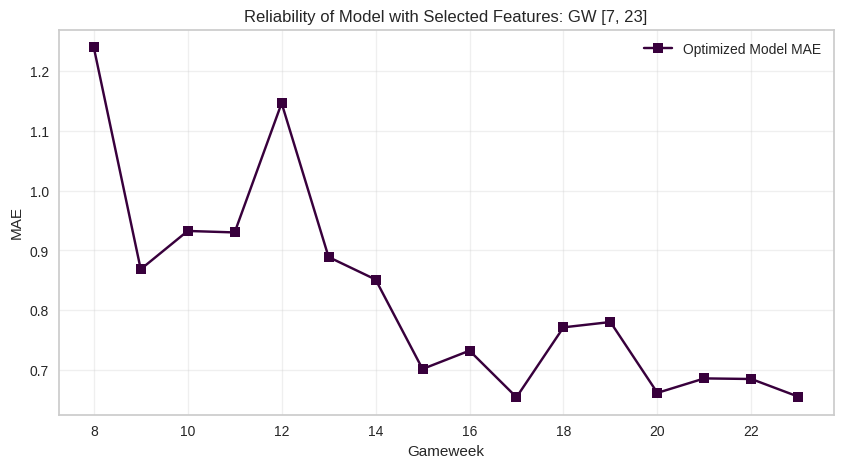

In [85]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(eval_metrics_.index, eval_metrics_['test_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [7, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 24-25


## Functions


In [5]:
def working_df(data, gw, features=None):
    data_24 = data[data['season'] == 2024]
    data_25 = data[data['season'] == 2025]

    GW_full = data_25['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data_25[train_mask]
    test_data = data_25[test_mask]

    train_data = pd.concat([data_24, train_data])

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'fpl_name': full_data[test_mask]['fpl_name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['fpl_name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


## Data Prep


In [6]:
# all_data = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
all_data = pd.read_csv('../Prediction with Affine PNN/data/all_data.csv')
all_data

,season,understat_id,round,h_goals,team_h_difficulty,chance_of_playing_next_round,goals_conceded,clearances_blocks_interceptions,selected_by_percent,season_clearances_blocks_interceptions,...,strength_defence_home_5_ewm,strength_defence_away_1_ewm,strength_defence_away_3_ewm,strength_defence_away_5_ewm,opponent_team_name,opp_clean_sheets,opp_elo_h,opp_elo_a,opp_elo,opp_strength
0,2024,65.0,1,0.0,2.0,0.0,0.0,0.0,0.3,0.0,...,0.000000,0.0,0.000000,0.000000,Leicester_2024,0.0,1741.20,1830.21,1741.20,0.0
1,2024,65.0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0,0.0,0.00,0.00,0.00,0.0
2,2024,65.0,3,0.0,2.0,0.0,1.0,2.0,0.2,0.0,...,0.000000,0.0,0.000000,0.000000,Newcastle_2024,0.0,1741.20,1830.21,1741.20,0.0
3,2024,65.0,4,0.0,5.0,0.0,0.0,0.0,0.2,2.0,...,0.000000,0.0,0.000000,0.000000,Arsenal_2024,1.0,1702.37,1981.59,1981.59,0.0
4,2024,65.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0,0.0,0.00,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62315,2025,14328.0,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.231503,0.0,1.230469,10.925164,0,0.0,0.00,0.00,0.00,0.0
62316,2025,14328.0,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.821002,0.0,0.615234,7.283443,0,0.0,0.00,0.00,0.00,0.0
62317,2025,14328.0,36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.547335,0.0,0.307617,4.855628,0,0.0,0.00,0.00,0.00,0.0
62318,2025,14328.0,37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.031556,0.0,0.153809,3.237086,0,0.0,0.00,0.00,0.00,0.0


In [23]:

# gw=24

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'season', 'opponent_team', 'was_home', 'xP_25',# 'xP_next',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'cbitr_volume_90', 'cbitr_ewm_90', 'cbitr_ewm_probability',  'cbitr_probability','elo',  'team_h_difficulty', 'team_a_difficulty',
    'win_prob', 'draw_prob', 'lose_prob',


    'creativity_rolling_1', 'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1',
    'threat_rolling_3', 'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3',
    'pts_bonus_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1',
    'expected_assists_rolling_3', 'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1',
    'expected_goals_conceded_rolling_3', 'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5',
    'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1',
    'key_passes_rolling_3', 'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5',
    'goals_rolling_1', 'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5',
    'saves_rolling_1', 'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3',
    'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5',
    'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1',
    'transfers_in_rolling_3', 'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5',

    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm',
    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm',
    'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm',
    'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm',
    'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm',
    'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm', 'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',
    'form_1_ewm', 'form_3_ewm', 'form_5_ewm', 'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',
    'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm',
    'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm',
    'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm',
    'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm',
    'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

all_data = all_data.rename({'web_name': 'fpl_name'}, axis=1)

all_data_24 = all_data[all_data['season'] == 2024]
all_data_25 = all_data[all_data['season'] == 2025]
all_data_24

hist_data_24 = all_data_24[
    # (all_data_24['round'] > 5)  &
    (all_data_24['minutes_rolling_3'] > 15) &
    (all_data_24['minutes'] > 15)
    ]

hist_data_25 = all_data_25[
    # (all_data_25['round'] > 5)  &
    (all_data_25['minutes_rolling_3'] > 15) &
    (all_data_25['minutes'] > 15)
    ]
# Cater for round = 1: rolling_3 = 0
hist_data_25_1 = all_data_25[
    (all_data_25['round'] == 1)  &
    # (all_data_25['minutes_rolling_3'] > 15) &
    (all_data_25['minutes'] > 15)
    ]

hist_data_25 = pd.concat([hist_data_25_1, hist_data_25])

# Make sure round = gw is include: it doesn't meet most of the filters
tar_data = all_data_25[
                        (all_data_25['round'] == gw) &
                        (all_data_25['minutes_rolling_3'] >= 15)
                    ]

all_data_ = pd.concat([hist_data_24, hist_data_25, tar_data])

active_data = all_data_[cols].copy()
active_data_ = active_data.copy()


CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
data = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)

feature_cols = [
 'selected_by_percent',
 'value',
 'transfers_in',
 'transfers_out',
 'selected',
 'ownership_change',
 'percenatge_net_transfers',
 'cbitr_volume_90',
 'cbitr_ewm_90',
 'cbitr_ewm_probability',
 'cbitr_probability',
 'elo',
 'team_h_difficulty',
 'team_a_difficulty',
 'win_prob',
 'draw_prob',
 'lose_prob',
 'creativity_rolling_1',
 'creativity_rolling_3',
 'creativity_rolling_5',
 'influence_rolling_1',
 'influence_rolling_3',
 'influence_rolling_5',
 'threat_rolling_1',
 'threat_rolling_3',
 'threat_rolling_5',
 'minutes_rolling_1',
 'minutes_rolling_3',
 'minutes_rolling_5',
 'pts_bonus_rolling_1',
 'pts_bonus_rolling_3',
 'pts_bonus_rolling_5',
 'expected_goals_rolling_1',
 'expected_goals_rolling_3',
 'expected_goals_rolling_5',
 'expected_assists_rolling_1',
 'expected_assists_rolling_3',
 'expected_assists_rolling_5',
 'xP_rolling_1',
 'xP_rolling_3',
 'xP_rolling_5',
 'expected_goals_conceded_rolling_1',
 'expected_goals_conceded_rolling_3',
 'expected_goals_conceded_rolling_5',
 'goals_conceded_rolling_1',
 'goals_conceded_rolling_3',
 'goals_conceded_rolling_5',
 'goals_scored_rolling_1',
 'goals_scored_rolling_3',
 'goals_scored_rolling_5',
 'shots_rolling_1',
 'shots_rolling_3',
 'shots_rolling_5',
 'key_passes_rolling_1',
 'key_passes_rolling_3',
 'key_passes_rolling_5',
 'npg_rolling_1',
 'npg_rolling_3',
 'npg_rolling_5',
 'npxG_rolling_1',
 'npxG_rolling_3',
 'npxG_rolling_5',
 'goals_rolling_1',
 'goals_rolling_3',
 'goals_rolling_5',
 'xG_rolling_1',
 'xG_rolling_3',
 'xG_rolling_5',
 'xA_rolling_1',
 'xA_rolling_3',
 'xA_rolling_5',
 'saves_rolling_1',
 'saves_rolling_3',
 'saves_rolling_5',
 'starts_rolling_1',
 'starts_rolling_3',
 'starts_rolling_5',
 'yellow_cards_rolling_1',
 'yellow_cards_rolling_3',
 'yellow_cards_rolling_5',
 'red_cards_rolling_1',
 'red_cards_rolling_3',
 'red_cards_rolling_5',
 'assists_rolling_1',
 'assists_rolling_3',
 'assists_rolling_5',
 'clean_sheets_rolling_1',
 'clean_sheets_rolling_3',
 'clean_sheets_rolling_5',
 'value_rolling_1',
 'value_rolling_3',
 'value_rolling_5',
 'ict_index_rolling_1',
 'ict_index_rolling_3',
 'ict_index_rolling_5',
 'selected_rolling_1',
 'selected_rolling_3',
 'selected_rolling_5',
 'transfers_in_rolling_1',
 'transfers_in_rolling_3',
 'transfers_in_rolling_5',
 'transfers_out_rolling_1',
 'transfers_out_rolling_3',
 'transfers_out_rolling_5',
 'ownership_change_rolling_1',
 'ownership_change_rolling_3',
 'ownership_change_rolling_5',
 'percenatge_net_transfers_rolling_1',
 'percenatge_net_transfers_rolling_3',
 'percenatge_net_transfers_rolling_5',
 'xGChain_rolling_1',
 'xGChain_rolling_3',
 'xGChain_rolling_5',
 'xGBuildup_rolling_1',
 'xGBuildup_rolling_3',
 'xGBuildup_rolling_5',
 'expected_goal_involvements_rolling_1',
 'expected_goal_involvements_rolling_3',
 'expected_goal_involvements_rolling_5',
 'form_rolling_1',
 'form_rolling_3',
 'form_rolling_5',
 'clearances_blocks_interceptions_rolling_1',
 'clearances_blocks_interceptions_rolling_3',
 'clearances_blocks_interceptions_rolling_5',
 'tackles_rolling_1',
 'tackles_rolling_3',
 'tackles_rolling_5',
 'recoveries_rolling_1',
 'recoveries_rolling_3',
 'recoveries_rolling_5',
 'selected_by_percent_rolling_1',
 'selected_by_percent_rolling_3',
 'selected_by_percent_rolling_5',
 'strength_rolling_1',
 'strength_rolling_3',
 'strength_rolling_5',
 'strength_overall_home_rolling_1',
 'strength_overall_home_rolling_3',
 'strength_overall_home_rolling_5',
 'strength_overall_away_rolling_1',
 'strength_overall_away_rolling_3',
 'strength_overall_away_rolling_5',
 'strength_attack_home_rolling_1',
 'strength_attack_home_rolling_3',
 'strength_attack_home_rolling_5',
 'strength_attack_away_rolling_1',
 'strength_attack_away_rolling_3',
 'strength_attack_away_rolling_5',
 'strength_defence_home_rolling_1',
 'strength_defence_home_rolling_3',
 'strength_defence_home_rolling_5',
 'strength_defence_away_rolling_1',
 'strength_defence_away_rolling_3',
 'strength_defence_away_rolling_5',
 'creativity_1_ewm',
 'creativity_3_ewm',
 'creativity_5_ewm',
 'influence_1_ewm',
 'influence_3_ewm',
 'influence_5_ewm',
 'threat_1_ewm',
 'threat_3_ewm',
 'threat_5_ewm',
 'minutes_1_ewm',
 'minutes_3_ewm',
 'minutes_5_ewm',
 'pts_bonus_1_ewm',
 'pts_bonus_3_ewm',
 'pts_bonus_5_ewm',
 'expected_goals_1_ewm',
 'expected_goals_3_ewm',
 'expected_goals_5_ewm',
 'expected_assists_1_ewm',
 'expected_assists_3_ewm',
 'expected_assists_5_ewm',
 'xP_1_ewm',
 'xP_3_ewm',
 'xP_5_ewm',
 'expected_goals_conceded_1_ewm',
 'expected_goals_conceded_3_ewm',
 'expected_goals_conceded_5_ewm',
 'goals_conceded_1_ewm',
 'goals_conceded_3_ewm',
 'goals_conceded_5_ewm',
 'goals_scored_1_ewm',
 'goals_scored_3_ewm',
 'goals_scored_5_ewm',
 'shots_1_ewm',
 'shots_3_ewm',
 'shots_5_ewm',
 'key_passes_1_ewm',
 'key_passes_3_ewm',
 'key_passes_5_ewm',
 'npg_1_ewm',
 'npg_3_ewm',
 'npg_5_ewm',
 'npxG_1_ewm',
 'npxG_3_ewm',
 'npxG_5_ewm',
 'goals_1_ewm',
 'goals_3_ewm',
 'goals_5_ewm',
 'xG_1_ewm',
 'xG_3_ewm',
 'xG_5_ewm',
 'xA_1_ewm',
 'xA_3_ewm',
 'xA_5_ewm',
 'saves_1_ewm',
 'saves_3_ewm',
 'saves_5_ewm',
 'starts_1_ewm',
 'starts_3_ewm',
 'starts_5_ewm',
 'yellow_cards_1_ewm',
 'yellow_cards_3_ewm',
 'yellow_cards_5_ewm',
 'red_cards_1_ewm',
 'red_cards_3_ewm',
 'red_cards_5_ewm',
 'assists_1_ewm',
 'assists_3_ewm',
 'assists_5_ewm',
 'clean_sheets_1_ewm',
 'clean_sheets_3_ewm',
 'clean_sheets_5_ewm',
 'value_1_ewm',
 'value_3_ewm',
 'value_5_ewm',
 'ict_index_1_ewm',
 'ict_index_3_ewm',
 'ict_index_5_ewm',
 'selected_1_ewm',
 'selected_3_ewm',
 'selected_5_ewm',
 'transfers_in_1_ewm',
 'transfers_in_3_ewm',
 'transfers_in_5_ewm',
 'transfers_out_1_ewm',
 'transfers_out_3_ewm',
 'transfers_out_5_ewm',
 'ownership_change_1_ewm',
 'ownership_change_3_ewm',
 'ownership_change_5_ewm',
 'percenatge_net_transfers_1_ewm',
 'percenatge_net_transfers_3_ewm',
 'percenatge_net_transfers_5_ewm',
 'xGChain_1_ewm',
 'xGChain_3_ewm',
 'xGChain_5_ewm',
 'xGBuildup_1_ewm',
 'xGBuildup_3_ewm',
 'xGBuildup_5_ewm',
 'expected_goal_involvements_1_ewm',
 'expected_goal_involvements_3_ewm',
 'expected_goal_involvements_5_ewm',
 'form_1_ewm',
 'form_3_ewm',
 'form_5_ewm',
 'clearances_blocks_interceptions_1_ewm',
 'clearances_blocks_interceptions_3_ewm',
 'clearances_blocks_interceptions_5_ewm',
 'tackles_1_ewm',
 'tackles_3_ewm',
 'tackles_5_ewm',
 'recoveries_1_ewm',
 'recoveries_3_ewm',
 'recoveries_5_ewm',
 'selected_by_percent_1_ewm',
 'selected_by_percent_3_ewm',
 'selected_by_percent_5_ewm',
 'strength_1_ewm',
 'strength_3_ewm',
 'strength_5_ewm',
 'strength_overall_home_1_ewm',
 'strength_overall_home_3_ewm',
 'strength_overall_home_5_ewm',
 'strength_overall_away_1_ewm',
 'strength_overall_away_3_ewm',
 'strength_overall_away_5_ewm',
 'strength_attack_home_1_ewm',
 'strength_attack_home_3_ewm',
 'strength_attack_home_5_ewm',
 'strength_attack_away_1_ewm',
 'strength_attack_away_3_ewm',
 'strength_attack_away_5_ewm',
 'strength_defence_home_1_ewm',
 'strength_defence_home_3_ewm',
 'strength_defence_home_5_ewm',
 'strength_defence_away_1_ewm',
 'strength_defence_away_3_ewm',
 'strength_defence_away_5_ewm',
 'opp_elo',
 'opp_clean_sheets',
 'opp_strength',
 'position_0',
 'position_DEF',
 'position_FWD',
 'position_GK',
 'position_MID',
 'team_0',
 'team_Arsenal_2024',
 'team_Arsenal_2025',
 'team_Aston Villa_2024',
 'team_Aston Villa_2025',
 'team_Bournemouth_2024',
 'team_Bournemouth_2025',
 'team_Brentford_2024',
 'team_Brentford_2025',
 'team_Brighton_2024',
 'team_Brighton_2025',
 'team_Burnley_2025',
 'team_Chelsea_2024',
 'team_Chelsea_2025',
 'team_Crystal Palace_2024',
 'team_Crystal Palace_2025',
 'team_Everton_2024',
 'team_Everton_2025',
 'team_Fulham_2024',
 'team_Fulham_2025',
 'team_Ipswich_2024',
 'team_Leeds_2025',
 'team_Leicester_2024',
 'team_Liverpool_2024',
 'team_Liverpool_2025',
 'team_Man City_2024',
 'team_Man City_2025',
 'team_Man Utd_2024',
 'team_Man Utd_2025',
 'team_Newcastle_2024',
 'team_Newcastle_2025',
 "team_Nott'm Forest_2024",
 "team_Nott'm Forest_2025",
 'team_Southampton_2024',
 'team_Spurs_2024',
 'team_Spurs_2025',
 'team_Sunderland_2025',
 'team_West Ham_2024',
 'team_West Ham_2025',
 'team_Wolves_2024',
 'team_Wolves_2025',
 'opponent_team_0',
 'opponent_team_Arsenal_2024',
 'opponent_team_Arsenal_2025',
 'opponent_team_Aston Villa_2024',
 'opponent_team_Aston Villa_2025',
 'opponent_team_Bournemouth_2024',
 'opponent_team_Bournemouth_2025',
 'opponent_team_Brentford_2024',
 'opponent_team_Brentford_2025',
 'opponent_team_Brighton_2024',
 'opponent_team_Brighton_2025',
 'opponent_team_Burnley_2025',
 'opponent_team_Chelsea_2024',
 'opponent_team_Chelsea_2025',
 'opponent_team_Crystal Palace_2024',
 'opponent_team_Crystal Palace_2025',
 'opponent_team_Everton_2024',
 'opponent_team_Everton_2025',
 'opponent_team_Fulham_2024',
 'opponent_team_Fulham_2025',
 'opponent_team_Ipswich_2024',
 'opponent_team_Leeds_2025',
 'opponent_team_Leicester_2024',
 'opponent_team_Liverpool_2024',
 'opponent_team_Liverpool_2025',
 'opponent_team_Man City_2024',
 'opponent_team_Man City_2025',
 'opponent_team_Man Utd_2024',
 'opponent_team_Man Utd_2025',
 'opponent_team_Newcastle_2024',
 'opponent_team_Newcastle_2025',
 "opponent_team_Nott'm Forest_2024",
 "opponent_team_Nott'm Forest_2025",
 'opponent_team_Southampton_2024',
 'opponent_team_Spurs_2024',
 'opponent_team_Spurs_2025',
 'opponent_team_Sunderland_2025',
 'opponent_team_West Ham_2024',
 'opponent_team_West Ham_2025',
 'opponent_team_Wolves_2024',
 'opponent_team_Wolves_2025'
]

data

,fpl_id,round,fpl_name,fpl_name,team_id,season,was_home,xP_25,selected_by_percent,value,...,opponent_team_Nott'm Forest_2024,opponent_team_Nott'm Forest_2025,opponent_team_Southampton_2024,opponent_team_Spurs_2024,opponent_team_Spurs_2025,opponent_team_Sunderland_2025,opponent_team_West Ham_2024,opponent_team_West Ham_2025,opponent_team_Wolves_2024,opponent_team_Wolves_2025
6,509.0,7,Werner,Werner,0.0,2024,False,2.2,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,509.0,8,Werner,Werner,0.0,2024,True,3.5,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8,509.0,9,Werner,Werner,0.0,2024,False,3.0,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,509.0,11,Werner,Werner,0.0,2024,True,0.3,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,509.0,15,Werner,Werner,0.0,2024,True,3.2,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58049,672.0,24,Hato,Hato,7.0,2025,True,0.0,0.2,46.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
58201,526.0,24,Igor Jesus,Igor Jesus,16.0,2025,True,0.0,1.0,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59037,731.0,24,Kevin,Kevin,10.0,2025,False,0.0,0.1,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59265,733.0,24,Lammens,Lammens,14.0,2025,True,0.0,1.8,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Importance


In [25]:

def select_best_features(df, features):
    """
    Ranks features using LightGBM feature importance.
    Tree models naturally calculate which features reduce variance the most.
    """
    reliable_df = df[df['round'] >= 6].copy()

    X = reliable_df[features]
    y = reliable_df['xP_25']

    # Use default params for ranking
    model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    model.fit(X, y)

    importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Add a 'Rank' column to match the previous structure
    importances['Rank'] = range(1, len(importances) + 1)
    return importances

def run_reliability_test(train_df, test_df, selected_features):
    """
    Simulates the season using only the selected features.
    """
    gws = sorted(train_df['round'].unique())
    results = []

    scaler = StandardScaler()

    # Hyperparameters to tune: Learning Rate and Complexity (num_leaves)
    learning_rates = [0.01, 0.05, 0.1]
    num_leaves_list = [15, 31, 63]

    best_gw_mae = float('inf')
    best_lr = 0.1
    best_leaves = 31

    # train_df = df[df['round'] < round]
    # test_df = df[df['round'] == round]

    X_train = scaler.fit_transform(train_df[selected_features])
    X_test = scaler.transform(test_df[selected_features])

    for lr in learning_rates:
        for leaves in num_leaves_list:
            val_model = LGBMRegressor(
                learning_rate=lr,
                num_leaves=leaves,
                n_estimators=100,
                random_state=42,
                verbose=-1
            )

            val_model.fit(X_train, train_df['xP_25'])
            v_mae = mean_absolute_error(test_df['xP_25'], val_model.predict(X_test))

            if v_mae < best_gw_mae:
                best_gw_mae = v_mae
                best_lr = lr
                best_leaves = leaves

    results.append({'GW': round, 'MAE': best_gw_mae, 'lr': best_lr, 'leaves': best_leaves})

    return pd.DataFrame(results)

# --- Execution ---
def get_gw_best_features(data, round, features):
    print(f"Step 1: Ranking Features for GW {round} using Recursive Feature Elimination...")
    data_24 = data[data['season'] == 2024]
    data_25 = data[data['season'] == 2025]

    GW_full = data_25['round'].values

    # Split
    GW_TRAIN_END = round - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data_25[train_mask]
    test_df = data_25[test_mask]

    train_df = pd.concat([data_24, train_data])

    # train_df = data[data['round'] < round]
    # test_df = data[data['round'] == round]

    feature_ranks = select_best_features(train_df,  feature_cols)

    # # Step 2: Automated Selection
    print(f"\nStep 2: Finding Optimal Feature Cut-off. of the {len(feature_cols)} features..")

    # We iterate through the top N features to find where MAE stops improving
    best_overall_mae = float('inf')
    best_overall_lr = 1
    best_overall_leaves = 31
    optimal_count = 1

    # Testing up to top 10 (or however many you want to check)
    search_limit = min(len(feature_cols), 50)


    for i in range(1, search_limit + 1):
        trial_features = feature_ranks.head(i)['Feature'].tolist()
        reliability_df = run_reliability_test(train_df, test_df, trial_features)


        avg_mae = reliability_df['MAE'].mean()
        avg_lr = reliability_df['lr'].mean()
        avg_leaves = reliability_df['leaves'].mean()


        print(f"Testing top {i} features: Average MAE = {avg_mae:.4f}")

        if avg_mae < best_overall_mae:
            best_overall_mae = avg_mae
            best_overall_lr = avg_lr
            best_overall_leaves = avg_leaves
            optimal_count = i


    # Final Prediction for the actual Deadline


    chosen_features = feature_ranks.head(optimal_count)['Feature'].tolist()

    final_model = LGBMRegressor(
        learning_rate=best_overall_lr,
        num_leaves=np.int64(best_overall_leaves),
        n_estimators=100,
        random_state=42,
        verbose=-1
    )
    print(best_overall_leaves, best_overall_lr)
    final_model.fit(train_df[chosen_features], train_df['xP_25'])
    actual_mae = mean_absolute_error(test_df['xP_25'], final_model.predict(test_df[chosen_features]))

    print(f"GW {round}: Used {len(chosen_features)} features. MAE: {actual_mae:.4f}")
    print(f"\nOptimal number of features: {optimal_count}")
    print(f"Selected Features: {round}==> {chosen_features}")

    return chosen_features, optimal_count, actual_mae, best_overall_lr, best_overall_leaves



In [26]:
selected_features = {}
for round in range(1,24):
    selected_features[round] = get_gw_best_features(data, round, feature_cols)


Step 1: Ranking Features for GW 1 using Recursive Feature Elimination...

Step 2: Finding Optimal Feature Cut-off. of the 383 features..
Testing top 1 features: Average MAE = 1.6175
Testing top 2 features: Average MAE = 1.6070
Testing top 3 features: Average MAE = 1.5971
Testing top 4 features: Average MAE = 1.5847
Testing top 5 features: Average MAE = 1.5468
Testing top 6 features: Average MAE = 1.4694
Testing top 7 features: Average MAE = 1.4652
Testing top 8 features: Average MAE = 1.4694
Testing top 9 features: Average MAE = 1.6556
Testing top 10 features: Average MAE = 1.6529
Testing top 11 features: Average MAE = 1.5711
Testing top 12 features: Average MAE = 1.5763
Testing top 13 features: Average MAE = 1.5173
Testing top 14 features: Average MAE = 1.5027
Testing top 15 features: Average MAE = 1.5077
Testing top 16 features: Average MAE = 1.5057
Testing top 17 features: Average MAE = 1.5014
Testing top 18 features: Average MAE = 1.4985
Testing top 19 features: Average MAE = 1.496

In [27]:
selections = pd.DataFrame(selected_features).T
selections.columns = ['best_features', 'optimal_count', 'best_overall_mae', 'best_lr', 'best_leaves']
selections

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves
1,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",7,1.466275,0.01,31.0
2,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",50,1.45304,0.1,31.0
3,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",11,0.832033,0.05,15.0
4,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",23,0.752499,0.1,31.0
5,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",18,0.660114,0.05,31.0
6,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",42,0.914248,0.1,63.0
7,"[draw_prob, win_prob, lose_prob, elo, percenat...",11,0.665653,0.1,15.0
8,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",43,0.953405,0.1,31.0
9,"[draw_prob, win_prob, lose_prob, elo, percenat...",11,0.636587,0.05,15.0
10,"[draw_prob, win_prob, lose_prob, percenatge_ne...",18,0.758242,0.1,15.0


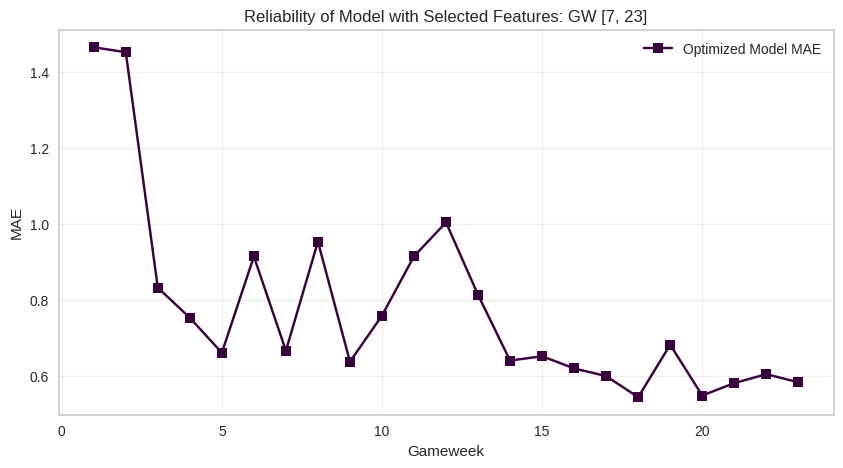

In [28]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections.index, selections['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [1, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
